# PoliMillionaire — Complete Experimental Notebook

This notebook documents every approach tried for the Politecnico di Milano
*"Who Wants to Be a Millionaire"* NLP competition. All experiments are
reproducible end-to-end on a **Google Colab T4 GPU** by running cells
top-to-bottom.

## Experimental Timeline

| Section | Approach | Key idea |
|---------|----------|----------|
| 2 | **Baseline** — zero/few-shot prompting | Test 13 open-weights models off-the-shelf |
| 3 | **SFT** — LoRA fine-tuning | Supervised training on AQuA-RAT math Q&A |
| 4 | **SFT + GRPO** — two-stage RL | Add policy optimisation after SFT |
| 5 | **OpenStax XML RAG** | Retrieve from algebra/calculus/stats textbooks |
| 6 | **Agentic RAG (TriviaQA-RC)** | Category routing + ChromaDB over trivia evidence |
| 7 | **Wikipedia Hybrid RAG** | BM25 + semantic over live Wikipedia pages |
| 8 | **Ensemble methods** | Soft voting, judge/debate, asymmetric hard voting |
| 9 | **Results** | Unified leaderboard across all approaches |
| 10 | **Speech** | : Whisper STT Pipeline |



## Section 1 — Setup & Shared Utilities

In [ ]:
%%capture
# 1.1  Install all packages needed across all sections (run once per runtime)
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes
!pip install -q transformers trl bitsandbytes accelerate peft \
    faiss-cpu sentence-transformers langchain-community langchain-huggingface \
    chromadb rank_bm25 beautifulsoup4 lxml nltk datasets pandas matplotlib \
    sympy wikipedia openai-whisper


### 1.2 Configuration — edit these once before running

In [ ]:
# 1.2  User-configurable variables
# CLIENT_DIR: folder that CONTAINS the millionaire_client/ package directory.
# If auto-discovery below fails, set this manually.
CLIENT_DIR          = "/content/gdrive/MyDrive/NLP_assignment_api_client"
TRIVIA_SEARCH_PATHS = ["/content/gdrive/MyDrive", "/content"]   # for triviaqa-rc
RESULTS_CSV         = "/content/gdrive/MyDrive/gerry_scotti/results/polimillionaire_results.csv"
API_URL             = "http://131.175.15.22:51111/"

# Credentials — set via Colab Secrets (Secrets tab on the left) or replace with strings
from google.colab import userdata, drive
USERNAME = userdata.get("POLIMIL_USER")
PASSWORD = userdata.get("POLIMIL_PASS")
HF_TOKEN = userdata.get("HF_TOKEN")

drive.mount("/content/gdrive", force_remount=False)


Mounted at /content/gdrive


### 1.3 MillionaireClient

In [ ]:
import sys, os

# Auto-discover the folder that contains millionaire_client/
# Searches Drive subdirectories so the path doesn't need to be exact.
_CANDIDATE_DIRS = [
    CLIENT_DIR,
    "/content/gdrive/MyDrive/gerry_scotti",
    "/content/gdrive/MyDrive/gerry_scotti/mmlu_explanations",
    "/content/gdrive/MyDrive/NLP_assignment_api_client",
    "/content/gdrive/MyDrive",
    "/content",
]

def _find_client():
    for d in _CANDIDATE_DIRS:
        if os.path.isdir(os.path.join(d, "millionaire_client")):
            return d
    # Broader search one level deeper into MyDrive
    mydrv = "/content/gdrive/MyDrive"
    if os.path.isdir(mydrv):
        for sub in os.listdir(mydrv):
            candidate = os.path.join(mydrv, sub)
            if os.path.isdir(os.path.join(candidate, "millionaire_client")):
                return candidate
    return None

_client_dir = _find_client()
if _client_dir is None:
    raise ImportError(
        "millionaire_client package not found.\n"
        "Set CLIENT_DIR in the config cell to the folder that contains "
        "'millionaire_client/' and re-run."
    )

print(f"millionaire_client found at: {_client_dir}")
if _client_dir not in sys.path:
    sys.path.insert(0, _client_dir)

from millionaire_client import MillionaireClient, GameError, TimeoutError

from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=False)

client = MillionaireClient(API_URL)
client.login(USERNAME, PASSWORD)

comps = client.competitions.list_all()
for c in comps:
    print(f"  [{c.id}] {c.name}  (max levels: {c.max_levels})")


millionaire_client found at: /content/gdrive/MyDrive/gerry_scotti
,  [0] Entertainment  (max levels: 15)
,  [1] Ancient History and Politics  (max levels: 15)
,  [2] Science and Nature  (max levels: 15)
,  [3] Maths  (max levels: 15)
,  [4] Philosophy and Psychology  (max levels: 15)
,  [5] News  (max levels: 15)


### 1.4 Model loading utility

In [ ]:
import gc, torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Shared 4-bit config used by every section that loads models
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

ensemble_models     = {}   # {name: model}
ensemble_tokenizers = {}   # {name: tokenizer}

def load_model(model_key: str, model_id: str, use_4bit: bool = True):
    """Load (or return cached) model+tokenizer; clears VRAM on first load."""
    if model_key in ensemble_models:
        return ensemble_models[model_key], ensemble_tokenizers[model_key]

    print(f"Loading {model_key} ({model_id})...")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True,
                                        clean_up_tokenization_spaces=False)
    kw = {"device_map": "auto", "trust_remote_code": True}
    if use_4bit:
        kw["quantization_config"] = bnb_config
    else:
        kw["torch_dtype"] = torch.float16

    mdl = AutoModelForCausalLM.from_pretrained(model_id, **kw)
    ensemble_tokenizers[model_key] = tok
    ensemble_models[model_key]     = mdl
    print(f"  {model_key} ready.")
    return mdl, tok

def clear_vram():
    """Unload all models and free GPU memory."""
    ensemble_models.clear()
    ensemble_tokenizers.clear()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("VRAM cleared.")


### 1.5 Universal benchmark runner

In [ ]:
import os, time, statistics, re
import pandas as pd
from datetime import datetime

def run_benchmark(client, answer_fn, competition_id: int,
                  target_runs: int = 30, anti_ban_pause: int = 15,
                  label: str = "") -> dict:
    """
    Universal benchmark runner used by every section.

    answer_fn signature:
        answer_fn(question_text: str, options: list, competition_id: int) -> int
    Returns a dict with mean_level, variance, max_level, all_levels.
    Appends one CSV row to RESULTS_CSV automatically.
    """
    levels_reached  = []
    successful_runs = 0
    run_label = label or getattr(answer_fn, "__name__", "unknown")

    print(f"\n{'='*60}")
    print(f"Benchmark: {run_label}  |  comp={competition_id}  |  runs={target_runs}")
    print(f"{'='*60}")

    while successful_runs < target_runs:
        print(f"[{successful_runs + 1}/{target_runs}] Starting game...", end=" ", flush=True)
        try:
            game = client.game.start(competition_id=competition_id)
            print("OK!")
            while game.in_progress:
                q = game.current_question
                if not q:
                    break
                aid = answer_fn(q.text, q.options, competition_id)
                game.answer(aid)

            levels_reached.append(game.current_level)
            successful_runs += 1
            print(f"  -> level={game.current_level}  earned=${game.earned_amount:,.0f}")

            if successful_runs < target_runs:
                time.sleep(anti_ban_pause)

        except Exception as exc:
            print(f"\n  [!] {exc} — retrying in 60 s...")
            time.sleep(60)

    if not levels_reached:
        return {}

    mean_val = statistics.mean(levels_reached)
    var_val  = statistics.variance(levels_reached) if len(levels_reached) > 1 else 0.0
    max_val  = max(levels_reached)
    result   = {"label": run_label, "competition_id": competition_id,
                "mean_level": round(mean_val, 2), "variance": round(var_val, 2),
                "max_level": max_val, "all_levels": levels_reached}

    print(f"\n  mean={mean_val:.2f}  var={var_val:.2f}  max={max_val}")

    row = pd.DataFrame([{
        "timestamp":      datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "label":          run_label,
        "competition_id": competition_id,
        "mean_level":     round(mean_val, 2),
        "variance":       round(var_val, 2),
        "max_level":      max_val,
    }])
    if os.path.isfile(RESULTS_CSV):
        row.to_csv(RESULTS_CSV, mode="a", header=False, index=False)
    else:
        row.to_csv(RESULTS_CSV, index=False)

    return result


### 1.6 Visualization utility

In [ ]:
import matplotlib.pyplot as plt

def plot_results(csv_path: str = RESULTS_CSV):
    """Horizontal bar chart of mean levels, sorted descending."""
    if not os.path.isfile(csv_path):
        print("No results CSV yet — run some benchmarks first.")
        return
    df = pd.read_csv(csv_path)
    df = df.sort_values("mean_level")
    fig, ax = plt.subplots(figsize=(10, max(4, len(df) * 0.45)))
    bars = ax.barh(df["label"], df["mean_level"], xerr=df["variance"] ** 0.5,
                   capsize=4, color="steelblue", alpha=0.8)
    ax.set_xlabel("Mean level reached (± std)")
    ax.set_title("PoliMillionaire — All Approaches Comparison")
    for bar, mx in zip(bars, df["max_level"]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"max={mx}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


## Section 2 — Baseline: Single-Model Zero/Few-Shot Testing

**Source:** `testing_modelli_singoli.ipynb`

We test 13 open-weights models with 0–3 shot prompting and optional
Chain-of-Thought (CoT) to establish a performance baseline without any
fine-tuning or retrieval.


In [ ]:
# 2.1  Model roster
MODEL_ROSTER = {
    "Gemma_2B":           "google/gemma-2-2b-it",
    "Gemma4_E2B":         "google/gemma-4-e2b-it",
    "Gemma4_E4B":         "google/gemma-4-e4b-it",
    "Llama_3B":           "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen_3B":            "Qwen/Qwen2.5-3B-Instruct",
    "Qwen_7B":            "Qwen/Qwen2.5-7B-Instruct",
    "Mistral_7B":         "mistralai/Mistral-7B-Instruct-v0.3",
    "Llama3.1_8B":        "meta-llama/Llama-3.1-8B-Instruct",
    "Mistral_Nemo_12B":   "mistralai/Mistral-Nemo-Instruct-2407",
    "Gemma3_12B":         "google/gemma-3-12b-it",
    "Qwen_14B":           "Qwen/Qwen2.5-14B-Instruct",
    "Phi4_14B":           "microsoft/phi-4",
    "Phi4_Reasoning_Plus":"microsoft/Phi-4-reasoning-plus",
}


In [ ]:
examples_db = {
        0: [
            {"user": "Q: Who directed 'Inception'?\n[0] Tarantino\n[1] Nolan\n[2] Spielberg\n[3] Cameron\n",
             "cot": "Nolan directed Inception. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: Which band released 'The Dark Side of the Moon'?\n[0] Pink Floyd\n[1] Beatles\n[2] Led Zeppelin\n[3] Queen\n",
             "cot": "Pink Floyd released it. [[0]]", "nocot": "[[0]]"},
            {"user": "Q: Walter White appears in which show?\n[0] Friends\n[1] Game of Thrones\n[2] Breaking Bad\n[3] Stranger Things\n",
             "cot": "Walter White is from Breaking Bad. [[2]]", "nocot": "[[2]]"},
        ],
        1: [
            {"user": "Q: First US President?\n[0] Jefferson\n[1] Lincoln\n[2] Washington\n[3] Adams\n",
             "cot": "George Washington was first. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: WWII ended in?\n[0] 1941\n[1] 1945\n[2] 1918\n[3] 1939\n",
             "cot": "WWII ended in 1945. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: Machu Picchu was built by?\n[0] Maya\n[1] Aztec\n[2] Inca\n[3] Olmec\n",
             "cot": "The Inca built Machu Picchu. [[2]]", "nocot": "[[2]]"},
        ],
        2: [
            {"user": "Q: Chemical symbol for Gold?\n[0] Au\n[1] Ag\n[2] Gd\n[3] Go\n",
             "cot": "Gold is Au from Latin aurum. [[0]]", "nocot": "[[0]]"},
            {"user": "Q: Red Planet?\n[0] Venus\n[1] Jupiter\n[2] Saturn\n[3] Mars\n",
             "cot": "Mars is the Red Planet. [[3]]", "nocot": "[[3]]"},
            {"user": "Q: Powerhouse of the cell?\n[0] Nucleus\n[1] Mitochondria\n[2] Ribosome\n[3] ER\n",
             "cot": "Mitochondria generate ATP. [[1]]", "nocot": "[[1]]"},
        ],
        3: [
            {"user": "Q: Square root of 144?\n[0] 10\n[1] 12\n[2] 14\n[3] 16\n",
             "cot": "12×12=144. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: 15% of 200?\n[0] 20\n[1] 25\n[2] 30\n[3] 35\n",
             "cot": "10%=20, 5%=10, total=30. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: Solve 2x+5=13\n[0] 3\n[1] 4\n[2] 5\n[3] 6\n",
             "cot": "2x=8, x=4. [[1]]", "nocot": "[[1]]"},
        ],
        4: [
            {"user": "Q: 'I think therefore I am' — who?\n[0] Plato\n[1] Kant\n[2] Descartes\n[3] Nietzsche\n",
             "cot": "Cogito ergo sum is Descartes. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: Holding contradictory beliefs causes?\n[0] Cognitive dissonance\n[1] Confirmation bias\n[2] Imposter syndrome\n[3] Conditioning\n",
             "cot": "Cognitive dissonance. [[0]]", "nocot": "[[0]]"},
            {"user": "Q: 'The Republic' was written by?\n[0] Aristotle\n[1] Socrates\n[2] Locke\n[3] Plato\n",
             "cot": "Plato wrote The Republic. [[3]]", "nocot": "[[3]]"},
        ],
        5: [
            {"user": "Q: Pandemic declarations are issued by?\n[0] UN\n[1] WHO\n[2] NATO\n[3] IMF\n",
             "cot": "WHO issues health alerts. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: Currency of most EU states?\n[0] Pound\n[1] Franc\n[2] Euro\n[3] Dollar\n",
             "cot": "The Euro is used by 20 EU members. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: UN headquarters city?\n[0] Geneva\n[1] New York\n[2] Brussels\n[3] Paris\n",
             "cot": "UN HQ is in New York. [[1]]", "nocot": "[[1]]"},
        ],
    }


In [ ]:
# 2.2  Core inference function with few-shot + CoT support
def ask_single_model(model_name, question_text, options, competition_id=0,
                     num_shots=0, use_cot=False):
    """
    Queries a single model.  Returns the winning option id (int).
    Supports 0–3 shot prompting and optional Chain-of-Thought.
    """
    # System prompt — role varies by category
    if use_cot:
        sys_prompts = {
            0: "You are an Entertainment expert. Explain in one sentence, then output the answer as [[number]].",
            1: "You are a Historian. Explain in one sentence, then output the answer as [[number]].",
            2: "You are a Scientist. Explain in one sentence, then output the answer as [[number]].",
            3: "You are a Mathematician. Explain in one sentence, then output the answer as [[number]].",
            4: "You are a Philosopher. Explain in one sentence, then output the answer as [[number]].",
            5: "You are a Journalist. Explain in one sentence, then output the answer as [[number]].",
        }
    else:
        sys_prompts = {
            0: "You are an Entertainment expert. Output ONLY [[number]].",
            1: "You are a Historian. Output ONLY [[number]].",
            2: "You are a Scientist. Output ONLY [[number]].",
            3: "You are a Mathematician. Output ONLY [[number]].",
            4: "You are a Philosopher. Output ONLY [[number]].",
            5: "You are a Journalist. Output ONLY [[number]].",
        }
    system_role = sys_prompts.get(competition_id,
                                  "You are a trivia expert. Output ONLY [[number]].")

    # Few-shot examples (3 per category)
    examples_db = {
        0: [
            {"user": "Q: Who directed 'Inception'?\n[0] Tarantino\n[1] Nolan\n[2] Spielberg\n[3] Cameron\n",
             "cot": "Nolan directed Inception. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: Which band released 'The Dark Side of the Moon'?\n[0] Pink Floyd\n[1] Beatles\n[2] Led Zeppelin\n[3] Queen\n",
             "cot": "Pink Floyd released it. [[0]]", "nocot": "[[0]]"},
            {"user": "Q: Walter White appears in which show?\n[0] Friends\n[1] Game of Thrones\n[2] Breaking Bad\n[3] Stranger Things\n",
             "cot": "Walter White is from Breaking Bad. [[2]]", "nocot": "[[2]]"},
        ],
        1: [
            {"user": "Q: First US President?\n[0] Jefferson\n[1] Lincoln\n[2] Washington\n[3] Adams\n",
             "cot": "George Washington was first. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: WWII ended in?\n[0] 1941\n[1] 1945\n[2] 1918\n[3] 1939\n",
             "cot": "WWII ended in 1945. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: Machu Picchu was built by?\n[0] Maya\n[1] Aztec\n[2] Inca\n[3] Olmec\n",
             "cot": "The Inca built Machu Picchu. [[2]]", "nocot": "[[2]]"},
        ],
        2: [
            {"user": "Q: Chemical symbol for Gold?\n[0] Au\n[1] Ag\n[2] Gd\n[3] Go\n",
             "cot": "Gold is Au from Latin aurum. [[0]]", "nocot": "[[0]]"},
            {"user": "Q: Red Planet?\n[0] Venus\n[1] Jupiter\n[2] Saturn\n[3] Mars\n",
             "cot": "Mars is the Red Planet. [[3]]", "nocot": "[[3]]"},
            {"user": "Q: Powerhouse of the cell?\n[0] Nucleus\n[1] Mitochondria\n[2] Ribosome\n[3] ER\n",
             "cot": "Mitochondria generate ATP. [[1]]", "nocot": "[[1]]"},
        ],
        3: [
            {"user": "Q: Square root of 144?\n[0] 10\n[1] 12\n[2] 14\n[3] 16\n",
             "cot": "12×12=144. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: 15% of 200?\n[0] 20\n[1] 25\n[2] 30\n[3] 35\n",
             "cot": "10%=20, 5%=10, total=30. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: Solve 2x+5=13\n[0] 3\n[1] 4\n[2] 5\n[3] 6\n",
             "cot": "2x=8, x=4. [[1]]", "nocot": "[[1]]"},
        ],
        4: [
            {"user": "Q: 'I think therefore I am' — who?\n[0] Plato\n[1] Kant\n[2] Descartes\n[3] Nietzsche\n",
             "cot": "Cogito ergo sum is Descartes. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: Holding contradictory beliefs causes?\n[0] Cognitive dissonance\n[1] Confirmation bias\n[2] Imposter syndrome\n[3] Conditioning\n",
             "cot": "Cognitive dissonance. [[0]]", "nocot": "[[0]]"},
            {"user": "Q: 'The Republic' was written by?\n[0] Aristotle\n[1] Socrates\n[2] Locke\n[3] Plato\n",
             "cot": "Plato wrote The Republic. [[3]]", "nocot": "[[3]]"},
        ],
        5: [
            {"user": "Q: Pandemic declarations are issued by?\n[0] UN\n[1] WHO\n[2] NATO\n[3] IMF\n",
             "cot": "WHO issues health alerts. [[1]]", "nocot": "[[1]]"},
            {"user": "Q: Currency of most EU states?\n[0] Pound\n[1] Franc\n[2] Euro\n[3] Dollar\n",
             "cot": "The Euro is used by 20 EU members. [[2]]", "nocot": "[[2]]"},
            {"user": "Q: UN headquarters city?\n[0] Geneva\n[1] New York\n[2] Brussels\n[3] Paris\n",
             "cot": "UN HQ is in New York. [[1]]", "nocot": "[[1]]"},
        ],
    }

    cat_examples = examples_db.get(competition_id, examples_db[0])
    chat = [{"role": "system", "content": system_role}]

    for ex in cat_examples[:min(num_shots, 3)]:
        user_txt = ex["user"] + (
            "\nReasoning + [[number]]: " if use_cot else "\n[[number]]: ")
        chat.append({"role": "user", "content": user_txt})
        chat.append({"role": "assistant",
                     "content": ex["cot"] if use_cot else ex["nocot"]})

    # Build actual question prompt
    prompt = f"Q: {question_text}\n"
    valid_ids = []
    for opt in options:
        prompt += f"[{opt.id}] {opt.text}\n"
        valid_ids.append(int(opt.id))
    prompt += "\nReasoning + [[number]]: " if use_cot else "\n[[number]]: "
    chat.append({"role": "user", "content": prompt})

    model = ensemble_models[model_name]
    tokenizer = ensemble_tokenizers[model_name]
    max_new = 80 if use_cot else 12

    try:
        enc = tokenizer.apply_chat_template(
            chat, tokenize=True, add_generation_prompt=True,
            return_tensors="pt", return_dict=True)
        input_ids    = enc["input_ids"].to(model.device)
        attention_mask = enc["attention_mask"].to(model.device)
    except Exception:
        raw = "\n".join(m["content"] for m in chat) + "\nAssistant:"
        enc = tokenizer(raw, return_tensors="pt").to(model.device)
        input_ids    = enc.input_ids
        attention_mask = enc.attention_mask

    with torch.no_grad():
        out = model.generate(input_ids=input_ids, attention_mask=attention_mask,
                             max_new_tokens=max_new, do_sample=False,
                             pad_token_id=tokenizer.eos_token_id)

    resp = tokenizer.decode(out[0][input_ids.shape[1]:],
                            skip_special_tokens=True).strip()

    m = re.search(r"\[\[(\d+)\]\]", resp)
    if m and int(m.group(1)) in valid_ids:
        return int(m.group(1))
    nums = [int(x) for x in re.findall(r"\d+", resp) if int(x) in valid_ids]
    if nums:
        return nums[-1] if use_cot else nums[0]
    return valid_ids[0]


In [ ]:
# Baseline benchmarking loop
# Configure which models and prompt styles to test.
# Each tested configuration appends one row to RESULTS_CSV.

BASELINE_CONFIGS = [
    ("Qwen_7B",  0, False),   # (model_key, num_shots, use_cot)
    ("Qwen_7B",  1, False),
    ("Qwen_7B",  1, True),
]

COMPETITION_ID = 0

for model_key, shots, cot in BASELINE_CONFIGS:
    model_id = MODEL_ROSTER[model_key]
    load_model(model_key, model_id, use_4bit=True)

    label = f"baseline_{model_key}_{shots}shot{'_cot' if cot else ''}"

    def _answer_fn(qt, opts, cid,
                   _mk=model_key, _sh=shots, _cot=cot):
        return ask_single_model(_mk, qt, opts, cid, _sh, _cot)

    run_benchmark(client, _answer_fn, COMPETITION_ID,
                  target_runs=5, label=label)
    clear_vram()

COMPETITION_ID = 1

for model_key, shots, cot in BASELINE_CONFIGS:
    model_id = MODEL_ROSTER[model_key]
    load_model(model_key, model_id, use_4bit=True)

    label = f"baseline_{model_key}_{shots}shot{'_cot' if cot else ''}"

    def _answer_fn(qt, opts, cid,
                   _mk=model_key, _sh=shots, _cot=cot):
        return ask_single_model(_mk, qt, opts, cid, _sh, _cot)

    run_benchmark(client, _answer_fn, COMPETITION_ID,
                  target_runs=5, label=label)
    clear_vram()

COMPETITION_ID = 2

for model_key, shots, cot in BASELINE_CONFIGS:
    model_id = MODEL_ROSTER[model_key]
    load_model(model_key, model_id, use_4bit=True)

    label = f"baseline_{model_key}_{shots}shot{'_cot' if cot else ''}"

    def _answer_fn(qt, opts, cid,
                   _mk=model_key, _sh=shots, _cot=cot):
        return ask_single_model(_mk, qt, opts, cid, _sh, _cot)

    run_benchmark(client, _answer_fn, COMPETITION_ID,
                  target_runs=5, label=label)
    clear_vram()

COMPETITION_ID = 3

for model_key, shots, cot in BASELINE_CONFIGS:
    model_id = MODEL_ROSTER[model_key]
    load_model(model_key, model_id, use_4bit=True)

    label = f"baseline_{model_key}_{shots}shot{'_cot' if cot else ''}"

    def _answer_fn(qt, opts, cid,
                   _mk=model_key, _sh=shots, _cot=cot):
        return ask_single_model(_mk, qt, opts, cid, _sh, _cot)

    run_benchmark(client, _answer_fn, COMPETITION_ID,
                  target_runs=5, label=label)
    clear_vram()

COMPETITION_ID = 4

for model_key, shots, cot in BASELINE_CONFIGS:
    model_id = MODEL_ROSTER[model_key]
    load_model(model_key, model_id, use_4bit=True)

    label = f"baseline_{model_key}_{shots}shot{'_cot' if cot else ''}"

    def _answer_fn(qt, opts, cid,
                   _mk=model_key, _sh=shots, _cot=cot):
        return ask_single_model(_mk, qt, opts, cid, _sh, _cot)

    run_benchmark(client, _answer_fn, COMPETITION_ID,
                  target_runs=5, label=label)
    clear_vram()

COMPETITION_ID = 5

for model_key, shots, cot in BASELINE_CONFIGS:
    model_id = MODEL_ROSTER[model_key]
    load_model(model_key, model_id, use_4bit=True)

    label = f"baseline_{model_key}_{shots}shot{'_cot' if cot else ''}"

    def _answer_fn(qt, opts, cid,
                   _mk=model_key, _sh=shots, _cot=cot):
        return ask_single_model(_mk, qt, opts, cid, _sh, _cot)

    run_benchmark(client, _answer_fn, COMPETITION_ID,
                  target_runs=15, label=label)
    clear_vram()

Loading Qwen_7B (Qwen/Qwen2.5-7B-Instruct)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Qwen_7B ready.
,
,============================================================
,Benchmark: baseline_Qwen_7B_0shot  |  comp=0  |  runs=5
,============================================================
,[1/5] Starting game... 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


OK!
,  -> level=5  earned=$500
,[2/5] Starting game... OK!
,  -> level=1  earned=$0
,[3/5] Starting game... OK!
,  -> level=3  earned=$200
,[4/5] Starting game... OK!
,  -> level=2  earned=$100
,[5/5] Starting game... OK!
,  -> level=6  earned=$1,000
,
,  mean=3.40  var=4.30  max=6
,VRAM cleared.
,Loading Qwen_7B (Qwen/Qwen2.5-7B-Instruct)...


...

  Qwen_7B ready.
,
,============================================================
,Benchmark: baseline_Qwen_7B_0shot  |  comp=5  |  runs=15
,============================================================
,[1/15] Starting game... OK!
,  -> level=2  earned=$100
,[2/15] Starting game... OK!
,  -> level=1  earned=$0
,[3/15] Starting game... OK!
,  -> level=1  earned=$0
,[4/15] Starting game... OK!
,  -> level=4  earned=$300
,[5/15] Starting game... OK!
,  -> level=3  earned=$200
,[6/15] Starting game... OK!
,  -> level=1  earned=$0
,[7/15] Starting game... OK!
,  -> level=5  earned=$500
,[8/15] Starting game... OK!
,  -> level=2  earned=$100
,[9/15] Starting game... OK!
,  -> level=5  earned=$500
,[10/15] Starting game... OK!
,  -> level=1  earned=$0
,[11/15] Starting game... OK!
,  -> level=3  earned=$200
,[12/15] Starting game... OK!
,  -> level=2  earned=$100
,[13/15] Starting game... OK!
,  -> level=1  earned=$0
,[14/15] Starting game... OK!
,  -> level=1  earned=$0
,[15/15] Starting game

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Qwen_7B ready.
,
,============================================================
,Benchmark: baseline_Qwen_7B_1shot  |  comp=5  |  runs=15
,============================================================
,[1/15] Starting game... OK!
,  -> level=1  earned=$0
,[2/15] Starting game... OK!
,  -> level=1  earned=$0
,[3/15] Starting game... OK!
,  -> level=1  earned=$0
,[4/15] Starting game... OK!
,  -> level=1  earned=$0
,[5/15] Starting game... OK!
,  -> level=1  earned=$0
,[6/15] Starting game... OK!
,  -> level=2  earned=$100
,[7/15] Starting game... OK!
,  -> level=3  earned=$200
,[8/15] Starting game... OK!
,  -> level=1  earned=$0
,[9/15] Starting game... OK!
,  -> level=1  earned=$0
,[10/15] Starting game... OK!
,  -> level=1  earned=$0
,[11/15] Starting game... OK!
,  -> level=6  earned=$1,000
,[12/15] Starting game... OK!
,  -> level=1  earned=$0
,[13/15] Starting game... OK!
,  -> level=1  earned=$0
,[14/15] Starting game... OK!
,  -> level=2  earned=$100
,[15/15] Starting game... OK

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Qwen_7B ready.
,
,============================================================
,Benchmark: baseline_Qwen_7B_1shot_cot  |  comp=5  |  runs=15
,============================================================
,[1/15] Starting game... OK!
,  -> level=1  earned=$0
,[2/15] Starting game... OK!
,  -> level=3  earned=$200
,[3/15] Starting game... OK!
,  -> level=2  earned=$100
,[4/15] Starting game... OK!
,  -> level=1  earned=$0
,[5/15] Starting game... OK!
,  -> level=3  earned=$200
,[6/15] Starting game... OK!
,  -> level=1  earned=$0
,[7/15] Starting game... OK!
,  -> level=4  earned=$300
,[8/15] Starting game... OK!
,  -> level=1  earned=$0
,[9/15] Starting game... OK!
,  -> level=1  earned=$0
,[10/15] Starting game... OK!
,  -> level=4  earned=$300
,[11/15] Starting game... OK!
,  -> level=2  earned=$100
,[12/15] Starting game... OK!
,  -> level=2  earned=$100
,[13/15] Starting game... OK!
,  -> level=1  earned=$0
,[14/15] Starting game... OK!
,  -> level=1  earned=$0
,[15/15] Starting ga

## Section 3 — Experiment A: SFT Fine-Tuning (LoRA on AQuA-RAT)

**Source:** `Qwen2_5_FineTuning_Math.ipynb`

We fine-tune `Qwen/Qwen2.5-Math-7B` with LoRA using Unsloth on
**10 000 samples** from AQuA-RAT for **250 steps** (effective batch 8,
≈ 40 % of the subset per training run).


In [ ]:
%%capture
# Unsloth must be imported before transformers for best performance
from unsloth import FastLanguageModel
from unsloth.chat_templates import train_on_responses_only

from unsloth.chat_templates import get_chat_template

SFT_MODEL_ID = "Qwen/Qwen2.5-Math-7B"
MAX_SEQ_LEN  = 1024

sft_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = SFT_MODEL_ID,
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit   = True,
    dtype          = None,
)

# Qwen2.5-Math-7B is the BASE model — it ships without a chat template.
# get_chat_template injects the standard ChatML / Qwen-2.5 template so that
# apply_chat_template() works correctly during both training and inference.
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")

sft_model = FastLanguageModel.get_peft_model(
    sft_model,
    r              = 8,
    target_modules = ["q_proj", "v_proj"],
    lora_alpha     = 16,
    lora_dropout   = 0.0,   # Fix 3: 0.0 keeps Unsloth fused kernels active
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
)
print(sft_model.print_trainable_parameters())


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
,are not enabled or a bias term (like in Qwen) is used.
,Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
,are not enabled or a bias term (like in Qwen) is used.
,Unsloth 2026.5.10 patched 28 layers with 28 QKV layers, 0 O layers and 0 MLP layers.


In [ ]:
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig

IDX_TO_LETTER = {0: "A", 1: "B", 2: "C", 3: "D"}
LETTER_TO_IDX = {v: k for k, v in IDX_TO_LETTER.items()}

SYSTEM_PROMPT = """You are a math EXPERT. Get the result step by step by providing an explanation on how to get the result. Then, you must respond with the letter (A, B, C or D) of the option associated with the correct result. You have only 500 tokens available. Here there are some examples:

Q: How many positive integers are factors of 120 and also factors of 40?
  A.1
  B.3
  C.8
  D.4

Explanation: Find the greatest common divisor (GCD) of 120 and 40, which is 40. The number of factors of 40 is found by prime factorization: $40 = 2^3 \times 5^1$. Number of factors is $(3+1) \times (1+1) = 4 \times 2 = 8$. Wait, the question asks for factors of *both* numbers, which means factors of $\text{GCD}(120, 40) = 40$. The number of factors of 40 is 8. Let's re-read the options. The options are A 1, B 3, C 8, D 4. Since 8 is an option, the answer is 8.
FINAL RESPONSE: C

Q: Statement 1 | If A is connected, the closure of A must be connected. Statement 2 | Every continuous function f : (0, 1) → (0, 1) has a fixed point.
  A. False, False
  B. True, True
  C. True, False
  D. False, True
Explanation: The closure of a connected set is connected. For the second statement, consider the function f(x) = x + 1/2. It has no fixed point in (0, 1).
FINAL RESPONSE: C"""

In [ ]:
def generate_conversation_sft(examples):
    """Format AQuA-RAT examples as chat for SFT training."""
    texts = []
    for q, opts, exp, ans in zip(examples["question"], examples["choices"],
                                  examples["explanation"], examples["answer_index"]):
        opts_txt = "\n".join(f"{o}" for i, o in enumerate(opts))
        convo = [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {"role": "user",
             "content": f"Q:{q}\n{opts_txt}"},
            {"role": "assistant",
             "content": f"Explanation:{exp.strip()}\nFINAL RESPONSE: {IDX_TO_LETTER[int(ans)]}"
                        + sft_tokenizer.eos_token},
        ]
        texts.append(sft_tokenizer.apply_chat_template(
            convo, tokenize=False, add_generation_prompt=False))
    return {"text": texts}

#10 K sample subset
dataset = (load_dataset("RikoteMaster/aqua-rat-mcqa", split="train")
           .shuffle(seed=42)
           .select(range(10_000))
           .map(generate_conversation_sft, batched=True,
                remove_columns=["question", "choices", "explanation", "answer_index", "answer_text"]))
print(f"Training examples: {len(dataset)}")

README.md:   0%|          | 0.00/1.73k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/130k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/83671 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/448 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training examples: 10000


In [ ]:
print(dataset[0]['text'])

<|im_start|>system
,You are a math EXPERT. Get the result step by step by providing an explanation on how to get the result. Then, you must respond with the letter (A, B, C or D) of the option associated with the correct result. You have only 500 tokens available. Here there are some examples:
,
,Q: How many positive integers are factors of 120 and also factors of 40?
,  A.1
,  B.3
,  C.8
,  D.4
,
,Explanation: Find the greatest common divisor (GCD) of 120 and 40, which is 40. The number of factors of 40 is found by prime factorization: $40 = 2^3 	imes 5^1$. Number of factors is $(3+1) 	imes (1+1) = 4 	imes 2 = 8$. Wait, the question asks for factors of *both* numbers, which means factors of $	ext{GCD}(120, 40) = 40$. The number of factors of 40 is 8. Let's re-read the options. The options are A 1, B 3, C 8, D 4. Since 8 is an option, the answer is 8.
,FINAL RESPONSE: C
,
,Q: Statement 1 | If A is connected, the closure of A must be connected. Statement 2 | Every continuous function f 

In [ ]:
# Memory fix: batch_size=1 + grad_accum=8 keeps effective batch=8 but
# halves peak activation memory vs. batch_size=2+grad_accum=4.
import gc
gc.collect(); torch.cuda.empty_cache()
print(f"GPU before SFT: {torch.cuda.memory_allocated()/1e9:.2f} GB "
      f"/ {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

sft_args = SFTConfig(
    dataset_text_field          = "text",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps                = 20,
    max_steps                   = 250,
    learning_rate               = 1e-4,
    logging_steps               = 25,
    optim                       = "adamw_8bit",
    weight_decay                = 0.01,
    lr_scheduler_type           = "cosine",
    max_grad_norm               = 1.0,
    seed                        = 3407,
    report_to                   = "none",
)

trainer_sft = SFTTrainer(
    model         = sft_model,
    tokenizer     = sft_tokenizer,
    train_dataset = dataset,
    args          = sft_args,
)
trainer_sft = train_on_responses_only(
    trainer_sft,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)

GPU before SFT: 5.57 GB / 15.6 GB


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/10000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=6):   0%|          | 0/10000 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
trainer_sft.train()
print("SFT training complete.")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
,==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
,   \\   /|    Num examples = 10,000 | Num Epochs = 1 | Total steps = 250
,O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
,\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
, "-____-"     Trainable parameters = 2,523,136 of 7,618,139,648 (0.03% trained)
,`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
,Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
25,1.602545
50,1.283075
75,1.035196
100,1.043456
125,0.985615
150,0.917539
175,0.968504
200,0.950783
225,0.875859
250,0.913522


SFT training complete.


In [ ]:
SFT_CKPT = "/content/gdrive/MyDrive/gerry_scotti/lora_models/qwen_math_sft"

In [ ]:
# Save checkpoint to Drive
sft_model.save_pretrained(SFT_CKPT)
sft_tokenizer.save_pretrained(SFT_CKPT)

In [ ]:
from transformers import TextStreamer

def get_ai_answer_sft(question_text, options, model=None, tokenizer=None):
    """Run SFT-trained Qwen2.5-Math-7B on a game question. Returns option id."""
    if model is None:
        model, tokenizer = sft_model, sft_tokenizer
    opts_txt = "\n".join(f"{IDX_TO_LETTER[opt.id]}. {opt.text}" for opt in options)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",
         "content": f"Question: {question_text}\nOptions:\n{opts_txt}"},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    in_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=500, do_sample=False,
                             repetition_penalty=1.1,
                             pad_token_id=tokenizer.eos_token_id)
    resp = tokenizer.decode(out[0][in_len:], skip_special_tokens=True)
    m = re.search(r"FINAL RESPONSE:\s*([A-D])", resp, re.IGNORECASE)
    return LETTER_TO_IDX.get(m.group(1).upper(), 0) if m else 0


FastLanguageModel.for_inference(sft_model)  # enable 2× inference optimisation
from unsloth.chat_templates import get_chat_template
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")
def _sft_answer_fn(qt, opts, cid):
    return get_ai_answer_sft(qt, opts)

run_benchmark(client, _sft_answer_fn, competition_id=3,
              target_runs=30, label="sft_qwen_math")



,============================================================
,Benchmark: sft_qwen_math  |  comp=3  |  runs=30
,============================================================
,[1/30] Starting game... OK!
,  -> level=1  earned=$0
,[2/30] Starting game... OK!
,  -> level=3  earned=$200
,[3/30] Starting game... OK!
,  -> level=6  earned=$1,000
,[4/30] Starting game... OK!
,  -> level=1  earned=$0
,[5/30] Starting game... OK!
,  -> level=1  earned=$0
,[6/30] Starting game... OK!
,  -> level=10  earned=$16,000
,[7/30] Starting game... OK!
,  -> level=2  earned=$100
,[8/30] Starting game... OK!
,  -> level=5  earned=$500
,[9/30] Starting game... OK!
,  -> level=2  earned=$100
,[10/30] Starting game... OK!
,  -> level=1  earned=$0
,[11/30] Starting game... OK!
,  -> level=2  earned=$100
,[12/30] Starting game... OK!
,  -> level=2  earned=$100
,[13/30] Starting game... OK!
,  -> level=1  earned=$0
,[14/30] Starting game... OK!
,  -> level=3  earned=$200
,[15/30] Starting game... OK!
,  -> level

{'label': 'sft_qwen_math',
 'competition_id': 3,
 'mean_level': 2.53,
 'variance': 3.91,
 'max_level': 10,
 'all_levels': [1,
  3,
  6,
  1,
  1,
  10,
  2,
  5,
  2,
  1,
  2,
  2,
  1,
  3,
  1,
  2,
  3,
  1,
  1,
  2,
  3,
  1,
  1,
  4,
  5,
  1,
  2,
  3,
  2,
  4]}

In [ ]:
# Free VRAM before loading Section 3B model, we must
import gc
del trainer_sft
del sft_model, sft_tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed. Available: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

VRAM freed. Available: 15.5 GB


## Section 3B — Experiment A2: SFT on AI-Enriched MMLU Explanations

**Source:** `Qwen25_Math_Ai_Generated_dataset_2.ipynb`

Unlike Section 3 which trains on AQuA-RAT (general maths Q&A), here we fine-tune
on the **5 MMLU math subsets** — the same four-option multiple-choice format as
the quiz — paired with **LLM-generated explanations** produced by Groq and cached
to Drive.

Key differences from SFT-A:
- **In-domain data**: MMLU questions match the quiz format exactly.
- **Richer explanations**: each example includes a worked explanation plus the
  explicit correct-answer statement (`The correct answer is X: ...`).
- **2 full epochs** instead of a fixed step count.

In [ ]:
%%capture
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template, train_on_responses_only
from trl import SFTTrainer, SFTConfig

sft_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "Qwen/Qwen2.5-Math-7B",
    max_seq_length = 1024,
    load_in_4bit   = True,
    dtype          = None,
)
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")

sft_model = FastLanguageModel.get_peft_model(
    sft_model,
    r              = 8,
    target_modules = ["q_proj", "v_proj"],
    lora_alpha     = 16,
    lora_dropout   = 0.0,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
)
print(sft_model.print_trainable_parameters())

In [ ]:
import json as _json
from datasets import load_dataset, concatenate_datasets

PROGRESS_FILE = "/content/gdrive/MyDrive/gerry_scotti/mmlu_explanations/mmlu_math_progress.json"

if not os.path.exists(PROGRESS_FILE):
    raise FileNotFoundError(
        f"Explanations JSON not found at {PROGRESS_FILE}.\n"
        "Run the Groq explanation-generation notebook first.")

with open(PROGRESS_FILE, "r", encoding="utf-8") as f:
    explanations_dict = _json.load(f)
print(f"Loaded {len(explanations_dict)} AI-generated explanations.")

MATH_SUBSETS_B = [
    "abstract_algebra", "college_mathematics",
    "elementary_mathematics", "high_school_mathematics",
    "high_school_statistics",
]
splits_b = [load_dataset("cais/mmlu", s, split="test") for s in MATH_SUBSETS_B]
dataset_raw_b = concatenate_datasets(splits_b)

original_indices  = sorted([int(k) for k in explanations_dict.keys()])
mmlu_dataset      = dataset_raw_b.select(original_indices)
explanations_list = [explanations_dict[str(idx)] for idx in original_indices]
mmlu_dataset      = mmlu_dataset.add_column("explanation", explanations_list)
print(f"Dataset ready: {len(mmlu_dataset)} examples with AI explanations.")

Loaded 1064 AI-generated explanations.


README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

abstract_algebra/test-00000-of-00001.par(…):   0%|          | 0.00/9.96k [00:00<?, ?B/s]

abstract_algebra/validation-00000-of-000(…):   0%|          | 0.00/3.73k [00:00<?, ?B/s]

...

high_school_statistics/dev-00000-of-0000(…):   0%|          | 0.00/6.07k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

Dataset ready: 1064 examples with AI explanations.


In [ ]:
def generate_conversation_mmlu(examples):
    """Format AI-enriched MMLU examples as chat for SFT training."""
    texts = []
    for question, options, exp, correct in zip(
        examples["question"], examples["choices"],
        examples["explanation"], examples["answer"]
    ):
        opts_txt       = "\n".join(f"{IDX_TO_LETTER[i]}. {o}"
                                    for i, o in enumerate(options))
        correct_letter = IDX_TO_LETTER[int(correct)]
        correct_text   = options[int(correct)]

        assistant_answer = (
            f"Explanation: {exp.strip()}\n"
            f"FINAL RESPONSE: {correct_letter}{sft_tokenizer.eos_token}"
        )
        convo = [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": f"Q: {question}\n{opts_txt}"},
            {"role": "assistant", "content": assistant_answer},
        ]
        texts.append(sft_tokenizer.apply_chat_template(
            convo, tokenize=False, add_generation_prompt=False))
    return {"text": texts}

dataset_mmlu_sft = mmlu_dataset.map(
    generate_conversation_mmlu, batched=True,
    remove_columns=["question", "choices", "explanation", "answer", "subject"])
print(f"Training examples: {len(dataset_mmlu_sft)}")
print(dataset_mmlu_sft[0]["text"])

Map:   0%|          | 0/1064 [00:00<?, ? examples/s]

Training examples: 1064
,<|im_start|>system
,You are a math EXPERT. Get the result step by step by providing an explanation on how to get the result. Then, you must respond with the letter (A, B, C or D) of the option associated with the correct result. You have only 500 tokens available. Here there are some examples:
,
,Q: How many positive integers are factors of 120 and also factors of 40?
,  A.1
,  B.3
,  C.8
,  D.4
,
,Explanation: Find the greatest common divisor (GCD) of 120 and 40, which is 40. The number of factors of 40 is found by prime factorization: $40 = 2^3 	imes 5^1$. Number of factors is $(3+1) 	imes (1+1) = 4 	imes 2 = 8$. Wait, the question asks for factors of *both* numbers, which means factors of $	ext{GCD}(120, 40) = 40$. The number of factors of 40 is 8. Let's re-read the options. The options are A 1, B 3, C 8, D 4. Since 8 is an option, the answer is 8.
,FINAL RESPONSE: C
,
,Q: Statement 1 | If A is connected, the closure of A must be connected. Statement 2 | Eve

In [ ]:
import gc; gc.collect(); torch.cuda.empty_cache()
print(f"GPU before SFT-B: {torch.cuda.memory_allocated()/1e9:.2f} GB")

mmlu_sft_args = SFTConfig(
    dataset_text_field         = "text",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps               = 20,
    num_train_epochs           = 2,
    learning_rate              = 2e-4,
    logging_steps              = 20,
    optim                      = "adamw_8bit",
    weight_decay               = 0.01,
    lr_scheduler_type          = "cosine",
    seed                       = 3407,
    report_to                  = "none",
)

trainer_mmlu = SFTTrainer(
    model         = sft_model,
    tokenizer     = sft_tokenizer,
    train_dataset = dataset_mmlu_sft,
    args          = mmlu_sft_args,
)
trainer_mmlu = train_on_responses_only(
    trainer_mmlu,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)

GPU before SFT-B: 5.57 GB


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1064 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/1064 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/1064 [00:00<?, ? examples/s]

In [ ]:
trainer_mmlu.train()
print("SFT-B training complete.")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
,   \\   /|    Num examples = 1,064 | Num Epochs = 2 | Total steps = 266
,O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
,\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
, "-____-"     Trainable parameters = 2,523,136 of 7,618,139,648 (0.03% trained)


Step,Training Loss
20,0.843495
40,0.722646
60,0.640113
80,0.541185
100,0.471770
120,0.438701
140,0.432484
160,0.427176
180,0.389405
200,0.415989


SFT-B training complete.


In [ ]:
SFT_MMLU_CKPT = "/content/gdrive/MyDrive/gerry_scotti/lora_models/qwen_math_sft_mmlu"

In [ ]:
# Save checkpoint to Drive
sft_model.save_pretrained(SFT_MMLU_CKPT)
sft_tokenizer.save_pretrained(SFT_MMLU_CKPT)

In [ ]:
FastLanguageModel.for_inference(sft_model)
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")
sft_model.generation_config.max_length = None  # remove conflicting default

def _sft_b_fn(qt, opts, cid):
    return get_ai_answer_sft(qt, opts)

run_benchmark(client, _sft_b_fn, competition_id=3,
              target_runs=30, label="sft_mmlu_ai")


,============================================================
,Benchmark: sft_mmlu_ai  |  comp=3  |  runs=30
,============================================================
,[1/30] Starting game... OK!
,  -> level=2  earned=$100
,[2/30] Starting game... OK!
,  -> level=1  earned=$0
,[3/30] Starting game... OK!
,  -> level=1  earned=$0
,[4/30] Starting game... OK!
,  -> level=1  earned=$0
,[5/30] Starting game... OK!
,  -> level=7  earned=$2,000
,[6/30] Starting game... OK!
,  -> level=2  earned=$100
,[7/30] Starting game... OK!
,  -> level=1  earned=$0
,[8/30] Starting game... OK!
,
,  [!] Could not connect to server at http://131.175.15.22:51111: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')) — retrying in 60 s...
,[8/30] Starting game... OK!
,  -> level=2  earned=$100
,[9/30] Starting game... OK!
,
,  [!] Could not connect to server at http://131.175.15.22:51111: ('Connection aborted.', RemoteDisconnected('Remote end closed connection with

{'label': 'sft_mmlu_ai',
 'competition_id': 3,
 'mean_level': 2.53,
 'variance': 5.5,
 'max_level': 9,
 'all_levels': [2,
  1,
  1,
  1,
  7,
  2,
  1,
  2,
  2,
  1,
  2,
  1,
  1,
  1,
  2,
  1,
  1,
  4,
  1,
  5,
  9,
  2,
  2,
  2,
  5,
  5,
  1,
  1,
  9,
  1]}

In [ ]:
del trainer_mmlu
del sft_model, sft_tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed. Available: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

VRAM freed. Available: 15.5 GB


## Section 4 — Experiment B: SFT + GRPO (Two-Stage RL)

**Source:** `Qwen25_FT+GRPO_Math_MMLU.ipynb`

We continue training the SFT checkpoint from Section 3 with
**Group Relative Policy Optimisation (GRPO)** on the 5 MMLU math subsets
(1 064 examples). The reward function penalises incorrect answers and
verbosity.


In [ ]:
from peft import PeftModel

sft_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "Qwen/Qwen2.5-Math-7B",   # base model
    max_seq_length = 2048,
    load_in_4bit   = True,
)
sft_model     = PeftModel.from_pretrained(sft_model, SFT_CKPT, is_trainable = True)  # attach adapters
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")
FastLanguageModel.for_training(sft_model)
print(f"SFT-AQuA checkpoint reloaded from {SFT_CKPT}")

==((====))==  Unsloth 2026.5.10: Fast Qwen2 patching. Transformers: 5.5.0.
,   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
,O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
,\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
, "-____-"     Free license: http://github.com/unslothai/unsloth
,Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

SFT-AQuA checkpoint reloaded from /content/gdrive/MyDrive/gerry_scotti/lora_models/qwen_math_sft


### GRPO dataset preparation

The GRPO training dataset is built from the five MMLU math subsets. Unlike SFT,
GRPO does not need gold explanations — only the prompt and the correct letter.
`prepare_grpo_dataset` formats each example as a chat prompt (system + user)
and stores the answer as a letter string (`A`/`B`/`C`/`D`), which the reward
functions use directly at training time.

In [ ]:
from datasets import concatenate_datasets

MMLU_SUBSETS = [
    "abstract_algebra", "college_mathematics",
    "elementary_mathematics", "high_school_mathematics",
    "high_school_statistics",
]

mmlu_splits = []
for subset in MMLU_SUBSETS:
    ds = load_dataset("cais/mmlu", subset, split="test")
    mmlu_splits.append(ds)
    print(f"  {subset}: {len(ds)} examples")

mmlu_full = concatenate_datasets(mmlu_splits)
print(f"Total MMLU math examples: {len(mmlu_full)}")

def prepare_grpo_dataset(examples):
    """Format MMLU examples for GRPOTrainer (prompt + answer, no assistant turn)."""
    prompts, answers = [], []
    for q, choices, ans in zip(examples["question"], examples["choices"],
                                examples["answer"]):
        opts_txt = "\n".join(f"{IDX_TO_LETTER[i]}. {o}"
                              for i, o in enumerate(choices))
        prompt = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"{q}\n{opts_txt}"},
        ]
        prompts.append(prompt)
        answers.append(IDX_TO_LETTER[int(ans)])
    return {"prompt": prompts, "answer": answers}

grpo_dataset = mmlu_full.map(
    prepare_grpo_dataset, batched=True,
    remove_columns=mmlu_full.column_names)
print(f"GRPO dataset: {len(grpo_dataset)} examples")


  abstract_algebra: 100 examples
,  college_mathematics: 100 examples
,  elementary_mathematics: 378 examples
,  high_school_mathematics: 270 examples
,  high_school_statistics: 216 examples
,Total MMLU math examples: 1064


Map:   0%|          | 0/1064 [00:00<?, ? examples/s]

GRPO dataset: 1064 examples


## Reward Functions

GRPO trains the model by generating multiple completions per question and scoring
each with four reward signals that are summed together.

- **`reward_correct`** — the primary signal: **+1.0** if the predicted letter
  matches the gold answer, **−0.5** otherwise or if no letter is found.
- **`reward_format`** — **+0.2** if `FINAL RESPONSE: X` is present, **−0.2**
  otherwise. Enforces the output format required by the game client.
- **`reward_length_penalty`** — applied only on correct answers: penalizes
  responses under 50 words or over 450 words, rewards the ideal range linearly
  up to **+0.2**. Keeps answers within the quiz time budget.
- **`reward_reasoning`** — **+0.3** if at least 20 words precede `FINAL
  RESPONSE:`, discouraging the model from outputting only the letter.

In [ ]:
import gc; gc.collect(); torch.cuda.empty_cache()
from trl import GRPOTrainer, GRPOConfig

def reward_correct(completions, answer, **kwargs):
    rewards = []
    for i, (completion, correct_letter) in enumerate(zip(completions, answer)):
        correct_letter = IDX_TO_LETTER[int(correct_letter)]
        text = completion if isinstance(completion, str) else completion[0]["content"]
        match = re.search(r'FINAL RESPONSE:\s*([A-D])', text, re.IGNORECASE)
        predicted = match.group(1).upper() if match else None
        reward = -0.5 if predicted is None else (1.0 if predicted == correct_letter else -0.5)
        rewards.append(reward)
        print(f"[{i}] correct={reward:.2f}  PRED={predicted} | GT={correct_letter}")
    return rewards

def reward_format(completions, **kwargs):
    rewards = []
    for i, completion in enumerate(completions):
        text = completion if isinstance(completion, str) else completion[0]["content"]
        has_final = bool(re.search(r'FINAL RESPONSE:\s*[A-D]', text, re.IGNORECASE))
        reward = 0.2 if has_final else -0.2
        rewards.append(reward)
        print(f"[{i}] format={reward:.2f}")
    return rewards

def reward_length_penalty(completions, answer, **kwargs):
    rewards = []
    for i, (completion, correct_letter) in enumerate(zip(completions, answer)):
        correct_letter = IDX_TO_LETTER[int(correct_letter)]
        text = completion if isinstance(completion, str) else completion[0]["content"]
        match = re.search(r'FINAL RESPONSE:\s*([A-D])', text, re.IGNORECASE)
        is_correct = match and match.group(1).upper() == correct_letter
        if not is_correct:
            rewards.append(0.0)
            print(f"[{i}] length=0.00  (wrong answer)")
            continue
        n_tokens = len(text.split())
        if n_tokens < 50:
            reward = -0.3
        elif n_tokens <= 450:
            reward = 0.2 * (n_tokens / 450)
        else:
            reward = -min((n_tokens - 450) / 450, 0.3)
        rewards.append(reward)
        print(f"[{i}] length={reward:.2f}  ({n_tokens} words)")
    return rewards

def reward_reasoning(completions, **kwargs):
    rewards = []
    for i, completion in enumerate(completions):
        text = completion if isinstance(completion, str) else completion[0]["content"]
        parts = re.split(r'FINAL RESPONSE:', text, flags=re.IGNORECASE)
        has_reasoning = len(parts) > 1 and len(parts[0].split()) > 20
        reward = 0.3 if has_reasoning else 0.0
        rewards.append(reward)
        print(f"[{i}] reasoning={reward:.2f}")
    return rewards


grpo_config = GRPOConfig(
    max_prompt_length          = 350,
    max_completion_length      = 450,
    num_generations            = 4,
    temperature                = 0.7,
    top_p                      = 0.9,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,
    max_steps                  = 100,   # Fix 3: doubled from 50
    learning_rate              = 1e-6,
    warmup_steps               = 5,
    optim                      = "adamw_8bit",
    weight_decay               = 0.01,
    lr_scheduler_type          = "cosine",
    logging_steps              = 10,
    seed                       = 3407,
    report_to                  = "none",
)

trainer_grpo = GRPOTrainer(
    model             = sft_model,
    processing_class  = sft_tokenizer,
    reward_funcs      = [reward_correct, reward_format, reward_length_penalty, reward_reasoning],
    args              = grpo_config,
    train_dataset     = grpo_dataset,
)


In [ ]:
print(f"GPU: {torch.cuda.memory_allocated()/1e9:.1f} GB before GRPO")
trainer_grpo.train()
print("GRPO training complete.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


GPU: 11.2 GB before GRPO


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
,   \\   /|    Num examples = 1,064 | Num Epochs = 1 | Total steps = 100
,O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
,\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
, "-____-"     Trainable parameters = 2,523,136 of 7,618,139,648 (0.03% trained)


[0] correct=1.00  PRED=D | GT=D
,[1] correct=1.00  PRED=D | GT=D
,[2] correct=1.00  PRED=D | GT=D
,[3] correct=1.00  PRED=D | GT=D
,[0] format=0.20
,[1] format=0.20
,[2] format=0.20
,[3] format=0.20
,[0] length=0.03  (66 words)
,[1] length=0.04  (79 words)
,[2] length=0.04  (91 words)
,[3] length=0.08  (185 words)
,[0] reasoning=0.30
,[1] reasoning=0.30
,[2] reasoning=0.30
,[3] reasoning=0.30


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_correct / mean,rewards / reward_correct / std,rewards / reward_format / mean,rewards / reward_format / std,rewards / reward_length_penalty / mean,rewards / reward_length_penalty / std,rewards / reward_reasoning / mean,rewards / reward_reasoning / std
10,0.000649,0.891533,0.302410,212.750000,118.400000,351.400000,0.325000,106.866667,73.400000,156.400000,0.649564,0.550000,0.236603,0.190000,0.020000,-0.020967,0.098153,0.172500,0.079641
20,0.000445,0.829256,0.524755,223.775000,52.000000,379.800000,0.325000,112.625002,52.000000,182.200000,0.445304,0.475000,0.409808,0.200000,0.000000,-0.018244,0.133892,0.172500,0.062321
30,0.001431,0.838967,0.499059,159.850000,17.900000,363.000000,0.275000,52.425000,17.900000,93.800000,1.431505,0.662500,0.398205,0.200000,0.000000,-0.113533,0.171558,0.090000,0.077321
40,0.000551,0.968156,0.604716,183.675000,36.800000,359.800000,0.275000,75.216667,36.800000,121.300000,0.551094,0.662500,0.461603,0.200000,0.000000,-0.066844,0.148138,0.172500,0.126962
50,0.000702,1.055056,0.393029,152.125000,57.700000,295.200000,0.200000,82.075002,57.700000,120.200000,0.701841,0.775000,0.300000,0.190000,0.020000,-0.112444,0.112795,0.202500,0.045000
60,0.000429,1.040922,0.263912,247.050000,65.000000,450.000000,0.450000,92.600001,65.000000,121.100000,0.428426,0.662500,0.075000,0.200000,0.000000,-0.054078,0.145297,0.232500,0.079641
70,0.000231,0.704222,0.334216,291.600000,118.400000,423.700000,0.500000,110.091669,73.400000,154.400000,0.231341,0.362500,0.161603,0.160000,0.063094,-0.013278,0.096121,0.195000,0.111962
80,0.000250,1.028311,0.421681,180.650000,53.800000,290.500000,0.225000,91.441669,53.800000,134.800000,0.250423,0.700000,0.236603,0.190000,0.020000,-0.071689,0.143481,0.210000,0.081962
90,0.000344,0.809922,0.513931,243.025000,82.800000,390.100000,0.400000,88.341668,37.800000,139.400000,0.344376,0.475000,0.323205,0.160000,0.040000,-0.027578,0.116893,0.202500,0.126962
100,0.000456,1.043544,0.451735,199.550000,45.300000,403.200000,0.275000,101.550002,45.300000,178.600000,0.455833,0.737500,0.311603,0.190000,0.020000,-0.048956,0.174345,0.165000,0.094641


[0] correct=-0.50  PRED=B | GT=A
,[1] correct=-0.50  PRED=B | GT=A
,[2] correct=-0.50  PRED=B | GT=A
,[3] correct=-0.50  PRED=B | GT=A
,[0] format=0.20
,[1] format=0.20
,[2] format=0.20
,[3] format=0.20
,[0] length=0.00  (wrong answer)
,[1] length=0.00  (wrong answer)
,[2] length=0.00  (wrong answer)
,[3] length=0.00  (wrong answer)
,[0] reasoning=0.00
,[1] reasoning=0.00
,[2] reasoning=0.00
,[3] reasoning=0.00
,[0] correct=1.00  PRED=B | GT=B
,[1] correct=1.00  PRED=B | GT=B
,[2] correct=1.00  PRED=B | GT=B
,[3] correct=1.00  PRED=B | GT=B
,[0] format=0.20
,[1] format=0.20
,[2] format=0.20
,[3] format=0.20
,[0] length=0.04  (85 words)
,[1] length=-0.30  (20 words)
,[2] length=0.10  (232 words)
,[3] length=0.03  (70 words)
,[0] reasoning=0.30
,[1] reasoning=0.00
,[2] reasoning=0.00
,[3] reasoning=0.30
,[0] correct=-0.50  PRED=D | GT=B
,[1] correct=-0.50  PRED=C | GT=B
,[2] correct=-0.50  PRED=C | GT=B
,[3] correct=-0.50  PRED=None | GT=B
,[0] format=0.20
,[1] format=0.20
,[2] format=0.

In [ ]:
GRPO_CKPT = "/content/gdrive/MyDrive/gerry_scotti/lora_models/qwen_math_grpo"

In [ ]:
# Save checkpoint to Drive
sft_model.save_pretrained(GRPO_CKPT)
sft_tokenizer.save_pretrained(GRPO_CKPT)

In [ ]:
# GRPO uses the same get_ai_answer_sft() function — model weights updated in-place

FastLanguageModel.for_inference(sft_model)
sft_model.generation_config.max_length = None
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")

def _grpo_answer_fn(qt, opts, cid):
    return get_ai_answer_sft(qt, opts)

run_benchmark(client, _grpo_answer_fn, competition_id=3,
              target_runs=30, label="sft_grpo_qwen_math")



,============================================================
,Benchmark: sft_grpo_qwen_math  |  comp=3  |  runs=30
,============================================================
,[1/30] Starting game... OK!
,  -> level=3  earned=$200
,[2/30] Starting game... OK!
,  -> level=1  earned=$0
,[3/30] Starting game... OK!
,  -> level=1  earned=$0
,[4/30] Starting game... OK!
,  -> level=3  earned=$200
,[5/30] Starting game... OK!
,  -> level=2  earned=$100
,[6/30] Starting game... OK!
,  -> level=6  earned=$1,000
,[7/30] Starting game... OK!
,  -> level=1  earned=$0
,[8/30] Starting game... OK!
,  -> level=2  earned=$100
,[9/30] Starting game... OK!
,  -> level=1  earned=$0
,[10/30] Starting game... OK!
,  -> level=1  earned=$0
,[11/30] Starting game... OK!
,  -> level=3  earned=$200
,[12/30] Starting game... OK!
,  -> level=1  earned=$0
,[13/30] Starting game... OK!
,  -> level=4  earned=$300
,[14/30] Starting game... OK!
,
,  [!] Could not connect to server at http://131.175.15.22:51111: (

{'label': 'sft_grpo_qwen_math',
 'competition_id': 3,
 'mean_level': 2.77,
 'variance': 3.91,
 'max_level': 8,
 'all_levels': [3,
  1,
  1,
  3,
  2,
  6,
  1,
  2,
  1,
  1,
  3,
  1,
  4,
  8,
  3,
  3,
  1,
  5,
  5,
  4,
  1,
  3,
  3,
  1,
  8,
  2,
  2,
  1,
  2,
  2]}

In [ ]:
del sft_model, sft_tokenizer, trainer_grpo
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed. Available: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

VRAM freed. Available: 15.5 GB


## Section 5 — RAG on OpenStax XML (GRPO base model)

**Source:** `rag_xml_math.ipynb`

We augment the best-performing model from Section 4 (SFT+GRPO) with
**Retrieval-Augmented Generation** over three open-source OpenStax textbooks:
College Algebra, Calculus, and Statistics. For each quiz question, the most
relevant passages are retrieved and injected into the prompt as reference
material, without any additional training.


In [ ]:
from peft import PeftModel

df_res = pd.read_csv(RESULTS_CSV)

def _get_mean(label):
    row = df_res[df_res["label"] == label]
    return row["mean_level"].values[0] if len(row) else -1

candidates = {
    "sft_qwen_math":      (SFT_CKPT,  _get_mean("sft_qwen_math")),
    "sft_mmlu_ai":        (SFT_MMLU_CKPT, _get_mean("sft_mmlu_ai")),
    "sft_grpo_qwen_math": (GRPO_CKPT, _get_mean("sft_grpo_qwen_math")),
}

best_label, (BEST_CKPT, best_mean) = max(candidates.items(), key=lambda x: x[1][1])

print("Mean levels per approach:")
for lbl, (_, m) in candidates.items():
    marker = " ← WINNER" if lbl == best_label else ""
    print(f"  {lbl}: {m:.2f}{marker}")

sft_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "Qwen/Qwen2.5-Math-7B",
    max_seq_length = 2048,
    load_in_4bit   = True,
)
sft_model     = PeftModel.from_pretrained(sft_model, BEST_CKPT)
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")
FastLanguageModel.for_inference(sft_model)
print(f"Model loaded: {best_label} (mean={best_mean:.2f})")

Mean levels per approach:
,  sft_qwen_math: 2.53
,  sft_mmlu_ai: 2.53
,  sft_grpo_qwen_math: 2.77 ← WINNER
,==((====))==  Unsloth 2026.5.10: Fast Qwen2 patching. Transformers: 5.5.0.
,   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
,O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
,\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
, "-____-"     Free license: http://github.com/unslothai/unsloth
,Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Model loaded: sft_grpo_qwen_math (mean=2.77)


In [ ]:
# Download OpenStax open-source textbooks (run once; ~200 MB total)
!git clone https://github.com/openstax/osbooks-college-algebra-bundle /content/osbooks-college-algebra-bundle
!git clone https://github.com/openstax/osbooks-calculus-bundle /content/osbooks-calculus-bundle
!git clone https://github.com/openstax/osbooks-statistics /content/osbooks-statistics

Cloning into '/content/osbooks-college-algebra-bundle'...
,remote: Enumerating objects: 7597, done.
,remote: Counting objects: 100% (676/676), done.
,remote: Compressing objects: 100% (151/151), done.
,remote: Total 7597 (delta 478), reused 558 (delta 393), pack-reused 6921 (from 2)
,Receiving objects: 100% (7597/7597), 193.38 MiB | 22.61 MiB/s, done.
,Resolving deltas: 100% (2846/2846), done.
,Updating files: 100% (3202/3202), done.
,Cloning into '/content/osbooks-calculus-bundle'...
,remote: Enumerating objects: 6899, done.
,remote: Counting objects: 100% (480/480), done.
,remote: Compressing objects: 100% (105/105), done.
,remote: Total 6899 (delta 351), reused 411 (delta 287), pack-reused 6419 (from 2)
,Receiving objects: 100% (6899/6899), 140.60 MiB | 28.51 MiB/s, done.
,Resolving deltas: 100% (3324/3324), done.
,Updating files: 100% (2084/2084), done.
,Cloning into '/content/osbooks-statistics'...
,remote: Enumerating objects: 1765, done.
,remote: Counting objects: 100% (64/64), 

### Corpus preparation: parsing and chunking

The three OpenStax repositories are parsed from their native CNXML/XML format
using BeautifulSoup. Each section's paragraphs, equations, examples and
exercises are merged into a single text block, then split into overlapping
chunks of ~200 words (overlap=30) using a sliding window. Stopwords are
removed from queries at retrieval time to focus on content words.

In [ ]:
from pathlib import Path
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)

XML_DIRS = ["/content/osbooks-college-algebra-bundle",
            "/content/osbooks-calculus-bundle",
            "/content/osbooks-statistics"]

STOP_WORDS = set(stopwords.words("english"))

def clean_text(t):
    return " ".join(t.split()).strip()

def extract_text_list(parent, tags):
    return [clean_text(el.get_text(" "))
            for el in parent.find_all(tags)
            if len(clean_text(el.get_text(" "))) > 20]

def parse_xml_file(path):
    with open(path, encoding="utf-8") as f:
        soup = BeautifulSoup(f, "lxml-xml")
    targets = soup.find_all(["section", "chapter"]) or \
              ([soup.find(["document", "body"])] if soup.find(["document", "body"]) else [])
    sections = []
    for sec in targets:
        title_tag = sec.find(lambda t: t.name in ["title", "md:title"])
        title = clean_text(title_tag.get_text(" ")) if title_tag else "Untitled"
        paragraphs = extract_text_list(sec, ["para", "p"])
        equations  = extract_text_list(sec, ["equation", "informalequation"])
        examples   = extract_text_list(sec, ["example"])
        exercises  = extract_text_list(sec, ["exercise", "problem"])
        if paragraphs or equations or examples or exercises:
            sections.append({"title": title, "paragraphs": paragraphs,
                             "equations": equations, "examples": examples,
                             "exercises": exercises})
    return sections

all_sections = []
for xml_dir in XML_DIRS:
    for xml_path in list(Path(xml_dir).rglob("*.xml")) + list(Path(xml_dir).rglob("*.cnxml")):
        if "collection.xml" in xml_path.name:
            continue
        try:
            all_sections.extend(parse_xml_file(xml_path))
        except Exception as e:
            pass

print(f"Sections loaded: {len(all_sections)}")

def chunk_text(text, chunk_size=200, overlap=30):
    words = text.split()
    chunks, step = [], chunk_size - overlap
    for i in range(0, len(words), step):
        chunk = " ".join(words[i:i + chunk_size])
        if len(chunk.split()) > 50:
            chunks.append(chunk)
    return chunks

all_chunks_raw = []
for sec in all_sections:
    title = sec["title"]
    full_text = "\n".join(sec["paragraphs"])
    if sec["equations"]:
        full_text += "\n" + " | ".join(sec["equations"])
    full_text += "\n" + "\n".join(sec["examples"])
    full_text += "\n" + "\n".join(sec["exercises"])

    for chunk in chunk_text(full_text, chunk_size=200, overlap=30):
        all_chunks_raw.append(f"SECTION: {title}\n{chunk}")

seen = set()
all_chunks = []
for chunk in all_chunks_raw:
    if chunk not in seen:
        seen.add(chunk)
        all_chunks.append(chunk)

print(f"Total chunks: {len(all_chunks)} ({len(all_chunks_raw) - len(all_chunks)} duplicates removed)")

Sections loaded: 3444
,Total chunks: 28235 (770 duplicates removed)


### Embedding and FAISS index

Each chunk is encoded with `all-MiniLM-L6-v2`, a lightweight sentence
transformer (~80 MB) effective for semantic retrieval. Embeddings are
L2-normalized and stored in a FAISS `IndexFlatIP` (exact inner product search,
equivalent to cosine similarity). At inference time the question is embedded
with the same model and the top-k most similar chunks are retrieved and
prepended to the prompt.

In [ ]:
import faiss, numpy as np
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2",
                               device="cuda" if torch.cuda.is_available() else "cpu")

print(f"Encoding {len(all_chunks)} chunks...")
embeddings = embedder.encode(all_chunks, batch_size=64,
                             normalize_embeddings=True,
                             show_progress_bar=True,
                             convert_to_numpy=True).astype("float32")

xml_index = faiss.IndexFlatIP(embeddings.shape[1])
xml_index.add(embeddings)
print(f"FAISS index: {xml_index.ntotal} vectors")

def remove_stopwords(text):
    return " ".join(w for w in text.lower().split() if w not in STOP_WORDS)

def retrieve_context_xml(question: str, k: int = 3) -> str:
    clean_q = remove_stopwords(question)
    q_vec = embedder.encode([clean_q], normalize_embeddings=True,
                            convert_to_numpy=True).astype("float32")
    _, idxs = xml_index.search(q_vec, k)
    return "\n\n".join(all_chunks[i] for i in idxs[0])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
,Key                     | Status     |  | 
,------------------------+------------+--+-
,embeddings.position_ids | UNEXPECTED |  | 
,
,Notes:
,- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 28235 chunks...


Batches:   0%|          | 0/442 [00:00<?, ?it/s]

FAISS index: 28235 vectors


### Retrieval test on sample questions

In [ ]:
test_q1 = "What is the derivative of x squared?"
test_q2 = "If a fair coin is flipped 3 times, what is the probability of getting exactly 2 heads?"

for test_q in [test_q1, test_q2]:
    context = retrieve_context_xml(test_q, k=2)
    print(f"Question: {test_q}")
    print(f"Query after stopword removal: {remove_stopwords(test_q)}")
    print(f"\n{'='*60}")
    print(f"Top 2 chunks retrieved from OpenStax corpus:")
    print(f"{'='*60}\n")
    for i, chunk in enumerate(context.split("\n\n"), 1):
        print(f"--- Chunk {i} ---")
        print(chunk)
        print()
    print("\n")

Question: What is the derivative of x squared?
,Query after stopword removal: derivative x squared?
,
,============================================================
,Top 2 chunks retrieved from OpenStax corpus:
,============================================================
,
,--- Chunk 1 ---
,SECTION: Derivative Functions
,, y ′ , d d x ( f ( x ) ) . | d y d x = lim Δ x → 0 Δ y Δ x . Finding the Derivative of a Square-Root Function Find the derivative of f ( x ) = x . Start directly with the definition of the derivative function. Use . f ′ ( x ) = lim h → 0 x + h − x h Substitute f ( x + h ) = x + h and f ( x ) = x into f ′ ( x ) = lim h → 0 f ( x + h ) − f ( x ) h . = lim h → 0 x + h − x h · x + h + x x + h + x Multiply numerator and denominator by x + h + x without distributing in the denominator. = lim h → 0 h h ( x + h + x ) Multiply the numerators and simplify. = lim h → 0 1 ( x + h + x ) Cancel the h . = 1 2 x Evaluate the limit. Finding the Derivative
,
,--- Chunk 2 ---
,SECTION: 

In [ ]:
def get_ai_answer_xml_rag(question_text, options):
    context = retrieve_context_xml(question_text, k=2)
    opts_txt = "\n".join(f"{IDX_TO_LETTER[opt.id]}. {opt.text}" for opt in options)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",
         "content": (f"Use the following reference material if relevant.\n\n"
                     f"[CONTEXT]\n{context}\n[/CONTEXT]\n\n"
                     f"Now answer the following question:"
                     f"Q: {question_text}:\n{opts_txt}")},
    ]
    text = sft_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    inputs = sft_tokenizer(text, return_tensors="pt").to(sft_model.device)
    in_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = sft_model.generate(**inputs, max_new_tokens=500, do_sample=False,
                                 repetition_penalty=1.1)
    resp = sft_tokenizer.decode(out[0][in_len:], skip_special_tokens=True)
    m = re.search(r"FINAL RESPONSE:\s*([A-D])", resp, re.IGNORECASE)
    return LETTER_TO_IDX.get(m.group(1).upper(), 0) if m else 0

def _xml_rag_fn(qt, opts, cid):
    return get_ai_answer_xml_rag(qt, opts)

sft_model.generation_config.max_length = None
sft_tokenizer = get_chat_template(sft_tokenizer, chat_template="qwen-2.5")

run_benchmark(client, _xml_rag_fn, competition_id=3,
              target_runs=30, label="xml_rag_grpo")


,============================================================
,Benchmark: xml_rag_embedding_prova  |  comp=3  |  runs=30
,============================================================
,[1/30] Starting game... OK!
,  -> level=1  earned=$0
,[2/30] Starting game... OK!
,  -> level=2  earned=$100
,[3/30] Starting game... OK!
,  -> level=3  earned=$200
,[4/30] Starting game... OK!
,  -> level=1  earned=$0
,[5/30] Starting game... OK!
,  -> level=2  earned=$100
,[6/30] Starting game... OK!
,  -> level=6  earned=$1,000
,[7/30] Starting game... OK!
,  -> level=3  earned=$200
,[8/30] Starting game... OK!
,  -> level=5  earned=$500
,[9/30] Starting game... OK!
,  -> level=2  earned=$100
,[10/30] Starting game... OK!
,  -> level=2  earned=$100
,[11/30] Starting game... OK!
,  -> level=8  earned=$4,000
,[12/30] Starting game... OK!
,  -> level=2  earned=$100
,[13/30] Starting game... OK!
,  -> level=3  earned=$200
,[14/30] Starting game... OK!
,  -> level=4  earned=$300
,[15/30] Starting game... O

{'label': 'xml_rag_embedding_prova',
 'competition_id': 3,
 'mean_level': 2.7,
 'variance': 2.84,
 'max_level': 8,
 'all_levels': [1,
  2,
  3,
  1,
  2,
  6,
  3,
  5,
  2,
  2,
  8,
  2,
  3,
  4,
  3,
  6,
  2,
  3,
  2,
  1,
  1,
  2,
  3,
  3,
  3,
  3,
  2,
  1,
  1,
  1]}

In [ ]:
del sft_model, sft_tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed. Available: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

VRAM freed. Available: 15.3 GB


## Section 6 — Experiment D: Agentic RAG (TriviaQA-RC)

**Source:** `rag_model_gemma4_v3.ipynb`

**Approach:** Category-based routing with ChromaDB over TriviaQA-RC evidence.
Math questions go to a Qwen2.5-Math-1.5B specialist; all other categories
use Gemma 4 E4B backed by a ChromaDB vector store built from TriviaQA-RC
Wikipedia evidence files.


In [ ]:
# Fix 1 — build_chroma_docs_from_triviaqa():
#   Reads DIRECTLY from triviaqa-rc.tar.gz (or pre-extracted dir).
#   Creates LangChain Documents from Q+A pairs + their Wikipedia evidence.
#
#   tar.gz approach: TWO targeted passes —
#     Pass 1: stream only the Q&A JSON file, collect needed evidence filenames.
#     Pass 2: stream only those specific evidence files (skip everything else).
#   This avoids loading all 75 K+ evidence files into memory.

import os, json, tarfile
from langchain_core.documents import Document

def build_chroma_docs_from_triviaqa(search_paths, max_qa=6000):
    """
    Returns a list of LangChain Documents ready for ChromaDB.
    Each document = Q + A + first-200-words of the linked Wikipedia article.
    Reads directly from triviaqa-rc.tar.gz; falls back to extracted directory.
    """

    def _read_ev(f_obj):
        raw = f_obj.read(2000)
        try:
            return " ".join(raw.decode("utf-8").split()[:200])
        except UnicodeDecodeError:
            return " ".join(raw.decode("latin-1").split()[:200])

    def _build_docs(qa_data, ev_cache):
        docs = []
        for item in qa_data:
            q   = item.get("Question", "").strip()
            ans = item.get("Answer", {}).get("Value", "").strip()
            if not (q and ans):
                continue
            ev = ""
            for ep in item.get("EntityPages", []):
                fname = ep.get("Filename", "")
                if fname and fname in ev_cache:
                    ev = ev_cache[fname]
                    break
            page = f"Q: {q}\nA: {ans}"
            if ev:
                page += f"\nEvidence: {ev}"
            docs.append(Document(page_content=page, metadata={"answer": ans}))
        return docs

    # ── Option A: pre-extracted directory ─────────────────────────────────────
    for base in search_paths:
        qa_path = os.path.join(base, "triviaqa-rc", "qa", "wikipedia-train.json")
        ev_dir  = os.path.join(base, "triviaqa-rc", "evidence", "wikipedia")
        if os.path.isfile(qa_path) and os.path.isdir(ev_dir):
            print(f"Reading TriviaQA-RC from extracted dir ({base})...")
            with open(qa_path) as f:
                qa_data = json.load(f)["Data"][:max_qa]  # key is "Data" (capital D)
            needed = {ep.get("Filename","")
                      for item in qa_data
                      for ep in item.get("EntityPages", [])}
            ev_cache = {}
            for fname in needed:
                fpath = os.path.join(ev_dir, fname)
                if os.path.isfile(fpath):
                    with open(fpath, "rb") as ef:
                        ev_cache[fname] = _read_ev(ef)
            docs = _build_docs(qa_data, ev_cache)
            print(f"  Documents built: {len(docs):,}")
            return docs

    # ── Option B: stream directly from triviaqa-rc.tar.gz ─────────────────────
    for base in search_paths:
        tar_path = os.path.join(base, "triviaqa-rc.tar.gz")
        if not os.path.isfile(tar_path):
            continue

        print(f"Reading TriviaQA-RC directly from tar.gz ({tar_path})...")

        # Pass 1 — find and load the Q&A JSON file only
        qa_data = None
        with tarfile.open(tar_path, "r:gz") as tf:
            for member in tf:
                if member.isfile() and member.name.endswith("wikipedia-train.json"):
                    with tf.extractfile(member) as f:
                        qa_data = json.load(f)["Data"][:max_qa]  # capital D
                    break   # stop decompressing; we have what we need
        if qa_data is None:
            raise FileNotFoundError("wikipedia-train.json not found in tar.gz.")

        needed = {ep.get("Filename","")
                  for item in qa_data
                  for ep in item.get("EntityPages", [])}
        print(f"  Q&A items: {len(qa_data):,} | Evidence files needed: {len(needed):,}")

        # Pass 2 — stream only the needed evidence files
        ev_cache = {}
        with tarfile.open(tar_path, "r:gz") as tf:
            for member in tf:
                if not (member.isfile() and "evidence/wikipedia/" in member.name):
                    continue
                fname = member.name.rsplit("/", 1)[-1]
                if fname in needed:
                    with tf.extractfile(member) as f:
                        ev_cache[fname] = _read_ev(f)

        print(f"  Evidence files loaded: {len(ev_cache):,}")
        docs = _build_docs(qa_data, ev_cache)
        print(f"  Documents built: {len(docs):,}")
        return docs

    raise FileNotFoundError(
        "TriviaQA-RC not found.\n"
        "Upload triviaqa-rc.tar.gz to Google Drive, or extract triviaqa-rc/ "
        "into a folder listed in TRIVIA_SEARCH_PATHS.")


In [ ]:
# 6.2  Category classification
CATEGORY_KEYWORDS = {
    "Maths": [
        "pythagorean", "fibonacci", "prime number", "square root",
        "trigonometry", "calculus", "algebra", "geometry", "theorem",
        "equation", "polynomial", "integral", "derivative", "matrix",
        "probability", "statistics", "fraction", "factorial", "logarithm",
        "quadratic", "binomial", "mathemat", "hypotenuse",
    ],
    "Entertainment": [
        "film", "movie", "actor", "actress", "director", "album", "song",
        "singer", "band", "celebrity", "sitcom", "television", "oscar",
        "hollywood", "musician", "concert", "lyrics", "box office",
    ],
    "Science and Nature": [
        "element", "atom", "molecule", "chemical", "biology", "physics",
        "species", "planet", "orbit", "gravity", "dna", "photosynthesis",
        "enzyme", "quantum", "periodic table", "evolution", "ecosystem",
    ],
    "Ancient History and Politics": [
        "roman", "greek", "pharaoh", "ancient egypt", "julius caesar",
        "dynasty", "medieval", "sparta", "athens", "ottoman",
        "crusade", "feudal", "emperor", "pyramid",
    ],
    "Philosophy": [
        "philosophy", "philosopher", "ethics", "metaphysics", "plato",
        "aristotle", "socrates", "kant", "descartes", "nietzsche",
        "existentialism", "utilitarianism", "stoicism",
    ],
    "News": [
        "president", "prime minister", "election", "government", "parliament",
        "treaty", "summit", "sanctions", "nato", "united nations",
        "war", "ceasefire", "referendum", "minister",
    ],
}

def classify_question(text: str) -> str:
    """Keyword-based category classifier. Returns the best-matching category."""
    text_lower = text.lower()
    scores = {cat: sum(1 for kw in kws if kw in text_lower)
              for cat, kws in CATEGORY_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "General"


In [ ]:
import gc, os
import torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Patch 1: allow unsloth to re-register bitsandbytes kernels without crashing
_orig_lib_impl = torch.library.Library.impl
def _safe_lib_impl(self, *args, **kwargs):
    try:
        return _orig_lib_impl(self, *args, **kwargs)
    except RuntimeError as e:
        if "already a kernel registered" in str(e):
            return
        raise
torch.library.Library.impl = _safe_lib_impl

# Patch 2: restore functional.get_ptr removed in bitsandbytes 0.49+
import bitsandbytes as bnb
if not hasattr(bnb, "functional"):
    class _FakeFunctional:
        @staticmethod
        def get_ptr(x):
            return x.data_ptr() if x is not None else None
    bnb.functional = _FakeFunctional()
elif not hasattr(bnb.functional, "get_ptr"):
    bnb.functional.get_ptr = lambda x: x.data_ptr() if x is not None else None

# ── Imports ───────────────────────────────────────────────────────────────────
from unsloth import FastLanguageModel
from datasets import load_dataset, Dataset
from trl import SFTTrainer, SFTConfig

# ── Config ────────────────────────────────────────────────────────────────────
LORA_RAG_CKPT   = "/content/gdrive/MyDrive/gemma4_rag_lora"
MODEL_ID        = "google/gemma-4-e4b-it"
MAX_SEQ_LEN     = 512
MAX_TRAIN_ITEMS = 60000
MAX_STEPS       = 200

# ── Load Gemma 4 E4B + LoRA adapters ─────────────────────────────────────────
lora_model, lora_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_ID,
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit   = True,
)
lora_model = FastLanguageModel.get_peft_model(
    lora_model,
    r              = 8,
    target_modules = ["q_proj", "v_proj"],
    lora_alpha     = 16,
    lora_dropout   = 0.0,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)
lora_model.print_trainable_parameters()

# ── Build TriviaQA-RC SFT dataset ────────────────────────────────────────────
print("Downloading TriviaQA-RC...")
trivia_hf = load_dataset("mandarjoshi/trivia_qa", "rc.wikipedia",
                          split="train").shuffle(seed=42).select(range(MAX_TRAIN_ITEMS))

# Optional: show category distribution over the sample
from collections import Counter
cat_counts = Counter()

records = []
for item in trivia_hf:
    q   = item["question"].strip()
    ans = item["answer"]["value"].strip()
    if not (q and ans):
        continue
    cat = classify_question(q)
    cat_counts[cat] += 1
    contexts = item.get("entity_pages", {}).get("wiki_context", [])
    ev       = " ".join(str(contexts[0]).split()[:500]) if contexts else ""
    context  = f"Evidence:\n{ev}\n\n" if ev else ""
    conv = [
        {"role": "user",
         "content": f"{context}Question: {q}\nAnswer with only the answer value."},
        {"role": "assistant", "content": ans},
    ]
    text = lora_tokenizer.apply_chat_template(conv, tokenize=False,
                                               add_generation_prompt=False)
    records.append({"text": text})

rag_sft_dataset = Dataset.from_list(records)
print(f"Dataset ready: {len(rag_sft_dataset):,} examples")
print("Category distribution:", dict(cat_counts.most_common()))

==((====))==  Unsloth 2026.5.10: Fast Gemma4 patching. Transformers: 5.5.0.
,   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
,O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
,\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
, "-____-"     Free license: http://github.com/unslothai/unsloth
,Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

trainable params: 3,510,272 || all params: 7,999,666,720 || trainable%: 0.0439
,Downloading TriviaQA-RC...


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Dataset ready: 60,000 examples
,Category distribution: {'General': 45599, 'Entertainment': 7425, 'News': 3840, 'Science and Nature': 1481, 'Ancient History and Politics': 1372, 'Maths': 192, 'Philosophy': 91}


In [ ]:
# ── Fine-tune ─────────────────────────────────────────────────────────────────
FastLanguageModel.for_training(lora_model)

trainer = SFTTrainer(
    model         = lora_model,
    tokenizer     = lora_tokenizer,
    train_dataset = rag_sft_dataset,
    args          = SFTConfig(
        dataset_text_field          = "text",
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_steps                = 10,
        max_steps                   = MAX_STEPS,
        learning_rate               = 2e-4,
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        logging_steps               = 20,
        optim                       = "adamw_8bit",
        weight_decay                = 0.01,
        lr_scheduler_type           = "cosine",
        output_dir                  = "/tmp/rag_lora_out",
        report_to                   = "none",
    ),
)
stats = trainer.train()
print(f"Done — loss: {stats.training_loss:.4f}")

# ── Save merged model to Drive ────────────────────────────────────────────────
print(f"Saving to {LORA_RAG_CKPT}...")
lora_model.save_pretrained_merged(LORA_RAG_CKPT, lora_tokenizer,
                                  save_method="merged_16bit")
print("Saved.")

# ── Free VRAM ─────────────────────────────────────────────────────────────────
del lora_model, lora_tokenizer, trainer, rag_sft_dataset
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed — {torch.cuda.mem_get_info()[0]/1e9:.2f} GB available")

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/60000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
,==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
,   \\   /|    Num examples = 60,000 | Num Epochs = 1 | Total steps = 200
,O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
,\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
, "-____-"     Trainable parameters = 3,510,272 of 7,999,666,720 (0.04% trained)


Step,Training Loss
20,1.155957
40,0.731420
60,0.623237
80,0.565973
100,0.526974
120,0.483285
140,0.472117
160,0.458845
180,0.461348
200,0.467791


Unsloth: Restored added_tokens_decoder metadata in /tmp/rag_lora_out/checkpoint-200/tokenizer_config.json.


Done — loss: 0.5947
,Saving to /content/gdrive/MyDrive/gemma4_rag_lora...


...

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
,Checking cache directory for required files...
,Cache check failed: model.safetensors not found in local cache.
,Not all required files found in cache. Will proceed with downloading.
,Checking cache directory for required files...
,Cache check failed: tokenizer.model not found in local cache.
,Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:53<00:00, 53.36s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [03:03<00:00, 183.38s/it]


Unsloth: Merge process complete. Saved to `/content/gdrive/MyDrive/gemma4_rag_lora`
,Saved.
,VRAM freed — 52.33 GB available


In [ ]:
%%capture
!pip install -q sympy wikipedia
!pip install -q duckduckgo-search


In [ ]:
from duckduckgo_search import DDGS

def _ddg_search(question: str, max_results: int = 3, timeout: float = 5.0) -> str:
    def _fetch():
        try:
            with DDGS() as ddgs:
                results = list(ddgs.text(question, max_results=max_results))
            return "\n".join(
                f"[{r.get('title','')}] {r.get('body','')}" for r in results
            ) if results else ""
        except Exception:
            return ""
    with ThreadPoolExecutor(max_workers=1) as ex:
        fut = ex.submit(_fetch)
        try:
            return fut.result(timeout=timeout) or ""
        except FuturesTimeout:
            return ""

In [ ]:
import tarfile, shutil, os, json
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name    = "BAAI/bge-small-en-v1.5",
    model_kwargs  = {"device": "cuda"},
    encode_kwargs = {"normalize_embeddings": True, "batch_size": 256},
)
VECTOR_DB_FULL_LOCAL = "/content/vector_db_full"
VECTOR_DB_FULL_DRIVE = "/content/gdrive/MyDrive/vector_db_full"

if os.path.isdir(VECTOR_DB_FULL_DRIVE) and len(os.listdir(VECTOR_DB_FULL_DRIVE)) > 0:
    if not os.path.isdir(VECTOR_DB_FULL_LOCAL):
        print("Restoring full vector DB from Drive...")
        shutil.copytree(VECTOR_DB_FULL_DRIVE, VECTOR_DB_FULL_LOCAL)
    vector_db_full = Chroma(persist_directory=VECTOR_DB_FULL_LOCAL,
                            embedding_function=embeddings)
    print(f"Full vector DB loaded: {vector_db_full._collection.count():,} entries")
else:
    all_docs_full = build_chroma_docs_full(TRIVIA_SEARCH_PATHS, max_qa=6000)
    vector_db_full = Chroma(embedding_function=embeddings,
                            persist_directory=VECTOR_DB_FULL_LOCAL)
    BATCH = 256
    for i in range(0, len(all_docs_full), BATCH):
        vector_db_full.add_documents(all_docs_full[i:i + BATCH])
        print(f"  {min(i+BATCH, len(all_docs_full)):,}/{len(all_docs_full):,}", end="\r")
    print("\nSyncing to Drive...")
    if os.path.isdir(VECTOR_DB_FULL_DRIVE):
        shutil.rmtree(VECTOR_DB_FULL_DRIVE)
    shutil.copytree(VECTOR_DB_FULL_LOCAL, VECTOR_DB_FULL_DRIVE)

In [ ]:
import os, shutil
from datasets import load_dataset
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from collections import Counter

EMBED_MODEL     = "BAAI/bge-small-en-v1.5"
VECTOR_DB_LOCAL = "/content/vector_db"
VECTOR_DB_DRIVE = "/content/gdrive/MyDrive/vector_db"

# ── Embedding model ───────────────────────────────────────────────────────────
print(f"Loading embedding model ({EMBED_MODEL})...")
embeddings = HuggingFaceEmbeddings(
    model_name    = EMBED_MODEL,
    model_kwargs  = {"device": "cuda"},
    encode_kwargs = {"normalize_embeddings": True, "batch_size": 256},
)

# ── Restore from Drive cache if available ────────────────────────────────────
if os.path.isdir(VECTOR_DB_DRIVE) and len(os.listdir(VECTOR_DB_DRIVE)) > 0:
    if not os.path.isdir(VECTOR_DB_LOCAL):
        print("Restoring vector DB from Drive...")
        shutil.copytree(VECTOR_DB_DRIVE, VECTOR_DB_LOCAL)
    vector_db = Chroma(persist_directory=VECTOR_DB_LOCAL,
                       embedding_function=embeddings)
    print(f"Vector DB loaded: {vector_db._collection.count():,} entries")

else:
    # ── Download full TriviaQA-RC training split ──────────────────────────────
    print("Downloading full TriviaQA-RC training split...")
    trivia_hf = load_dataset("mandarjoshi/trivia_qa", "rc.wikipedia",
                              split="train").shuffle(seed=42)
    print(f"Total examples: {len(trivia_hf):,}")

    # ── Build LangChain Documents ─────────────────────────────────────────────
    cat_counts = Counter()
    docs = []
    for item in trivia_hf:
        q   = item["question"].strip()
        ans = item["answer"]["value"].strip()
        if not (q and ans):
            continue
        cat = classify_question(q)
        cat_counts[cat] += 1
        contexts = item.get("entity_pages", {}).get("wiki_context", [])
        ev = " ".join(str(contexts[0]).split()[:1500]) if contexts else ""
        page = f"Q: {q}\nA: {ans}"
        if ev:
            page += f"\nEvidence: {ev}"
        docs.append(Document(page_content=page, metadata={"answer": ans, "category": cat}))

    print(f"Documents built: {len(docs):,}")
    print("Category distribution:", dict(cat_counts.most_common()))

    # ── Build ChromaDB in batches ─────────────────────────────────────────────
    vector_db = Chroma(embedding_function=embeddings,
                       persist_directory=VECTOR_DB_LOCAL)
    BATCH     = 128
    LOG_EVERY = 10
    total     = len(docs)
    for i in range(0, total, BATCH):
        vector_db.add_documents(docs[i:i + BATCH])
        if (i // BATCH) % LOG_EVERY == 0:
            print(f"  Indexed {min(i+BATCH, total):,}/{total:,}", flush=True)

    # ── Sync to Drive ─────────────────────────────────────────────────────────
    print("\nSyncing to Drive...")
    if os.path.isdir(VECTOR_DB_DRIVE):
        shutil.rmtree(VECTOR_DB_DRIVE)
    shutil.copytree(VECTOR_DB_LOCAL, VECTOR_DB_DRIVE)
    print(f"Vector DB ready: {vector_db._collection.count():,} entries")

# ── Patch retriever ───────────────────────────────────────────────────────────
def _retrieve(question: str, cat, k: int = 5) -> str:
    docs = vector_db.similarity_search(question, k=k)
    return "\n".join(d.page_content[:1000] for d in docs)


Loading embedding model (BAAI/bge-small-en-v1.5)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
,Key                     | Status     |  | 
,------------------------+------------+--+-
,embeddings.position_ids | UNEXPECTED |  | 
,
,Notes:
,- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Total examples: 61,888
,Documents built: 61,888
,Category distribution: {'General': 47028, 'Entertainment': 7664, 'News': 3951, 'Science and Nature': 1531, 'Ancient History and Politics': 1422, 'Maths': 198, 'Philosophy': 94}
,  Indexed 128/61,888
,  Indexed 1,408/61,888
,  Indexed 2,688/61,888
,  Indexed 3,968/61,888
,  Indexed 5,248/61,888
,  Indexed 6,528/61,888
,  Indexed 7,808/61,888
,  Indexed 9,088/61,888
,  Indexed 10,368/61,888
,  Indexed 11,648/61,888
,  Indexed 12,928/61,888
,  Indexed 14,208/61,888
,  Indexed 15,488/61,888
,  Indexed 16,768/61,888
,  Indexed 18,048/61,888
,  Indexed 19,328/61,888
,  Indexed 20,608/61,888
,  Indexed 21,888/61,888
,  Indexed 23,168/61,888
,  Indexed 24,448/61,888
,  Indexed 25,728/61,888
,  Indexed 27,008/61,888
,  Indexed 28,288/61,888
,  Indexed 29,568/61,888
,  Indexed 30,848/61,888
,  Indexed 32,128/61,888
,  Indexed 33,408/61,888
,  Indexed 34,688/61,888
,  Indexed 35,968/61,888
,  Indexed 37,248/61,888
,  Indexed 38,528/61,888
,  Indexe

In [ ]:
import math, random, io, contextlib, wikipedia
from sympy import (sqrt, Rational, pi, E, factorial, isprime, symbols,
                   sympify, Symbol)
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FuturesTimeout
from duckduckgo_search import DDGS   # ← fixed

# ── Ensure models are loaded ──────────────────────────────────────────────────
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

if "Gemma4_E4B" not in ensemble_models:
    load_model("Gemma4_E4B", "google/gemma-4-e4b-it", use_4bit=True)
if "QwenMath_1.5B" not in ensemble_models:
    load_model("QwenMath_1.5B", "Qwen/Qwen2.5-Math-1.5B-Instruct", use_4bit=True)

Loading Gemma4_E4B (google/gemma-4-e4b-it)...


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

  Gemma4_E4B ready.
,Loading QwenMath_1.5B (Qwen/Qwen2.5-Math-1.5B-Instruct)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  QwenMath_1.5B ready.


In [ ]:
%%capture
!pip uninstall duckduckgo_search -y
!pip install ddgs -q

In [ ]:
# Full agentic pipeline — Section 6
import math, random, io, contextlib, wikipedia
from sympy import (sqrt, Rational, pi, E, factorial, isprime, symbols,
                   sympify, Symbol)
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FuturesTimeout
from ddgs import DDGS

def _gemma():
    return ensemble_models["Gemma4_E4B"], ensemble_tokenizers["Gemma4_E4B"]
def _qwen_math():
    return ensemble_models["QwenMath_1.5B"], ensemble_tokenizers["QwenMath_1.5B"]

RAG_WIKI_THRESHOLD = 120

CAT_MAP = {
    "entertainment":                "Entertainment",
    "ancient history and politics": "Ancient History and Politics",
    "science and nature":           "Science and Nature",
    "maths":                        "Maths",
    "philosophy":                   "Philosophy",
    "psychology":                   "Psychology",
    "news":                         "News",
}

def _internal_cat(comp_cat: str):
    return CAT_MAP.get(comp_cat.lower().strip())

def _format_options(options):
    if isinstance(options, dict):
        text = "\n".join(f"{k}: {v}" for k, v in options.items())
    else:
        text = "\n".join(f"{opt.id}: {opt.text}" for opt in options)
    return text, len(options)

def _plain_opts(options):
    if isinstance(options, dict):
        return list(options.values())
    return [opt.text for opt in options]

def _extract_index(raw: str, n_opts: int) -> int:
    for m in re.finditer(r"\b(\d+)\b", raw):
        idx = int(m.group(1))
        if 0 <= idx < n_opts:
            return idx
    return 0

# ── Agent 1: ChromaDB retrieval ───────────────────────────────────────────────
def _retrieve(question: str, cat, k: int = 5) -> str:
    docs = vector_db.similarity_search(question, k=k)
    return "\n".join(d.page_content[:1000] for d in docs)

# ── Agent 2: Wikipedia ────────────────────────────────────────────────────────
def _wikipedia_search(question: str, sentences: int = 3, timeout: float = 4.0) -> str:
    def _fetch():
        try:
            hits = wikipedia.search(question, results=3)
            if not hits:
                return ""
            try:
                summary = wikipedia.summary(hits[0], sentences=sentences,
                                            auto_suggest=False)
                return f"[Wikipedia: {hits[0]}]\n{summary}"
            except wikipedia.exceptions.DisambiguationError as e:
                summary = wikipedia.summary(e.options[0], sentences=sentences,
                                            auto_suggest=False)
                return f"[Wikipedia: {e.options[0]}]\n{summary}"
        except Exception:
            return ""
    with ThreadPoolExecutor(max_workers=1) as ex:
        fut = ex.submit(_fetch)
        try:
            return fut.result(timeout=timeout) or ""
        except FuturesTimeout:
            return ""

# ── Agent 3: DuckDuckGo ───────────────────────────────────────────────────────
def _ddg_search(question: str, max_results: int = 3, timeout: float = 5.0) -> str:
    def _fetch():
        try:
            with DDGS() as ddgs:
                results = list(ddgs.text(question, max_results=max_results))
            return "\n".join(
                f"[{r.get('title','')}] {r.get('body','')}" for r in results
            ) if results else ""
        except Exception:
            return ""
    with ThreadPoolExecutor(max_workers=1) as ex:
        fut = ex.submit(_fetch)
        try:
            return fut.result(timeout=timeout) or ""
        except FuturesTimeout:
            return ""

# ── Agent 4: Calculator ───────────────────────────────────────────────────────
def _calc(expr: str):
    try:
        clean = (expr.replace("×","*").replace("÷","/").replace("^","**")
                     .replace(",","").replace(" ",""))
        return float(eval(clean, {"__builtins__": {}},
                          {"sqrt": math.sqrt, "pi": math.pi, "e": math.e}))
    except Exception:
        return None

def _should_run_calc(cat, plain_options):
    if cat == "Maths":
        return True
    num_count = sum(1 for o in plain_options
                    if re.match(r"^[\d\s\+\-\*\/\.\,\%°]+$", o.strip()))
    return num_count >= 2

def _calculator(question: str, plain_options: list) -> str:
    found = []
    opt_vals = {}
    for i, opt in enumerate(plain_options):
        v = _calc(opt)
        if v is not None:
            opt_vals[i] = v
            found.append(f"Option {i} '{opt}' = {v:.6g}")
    q_computed = []
    for m in re.finditer(r"\d+(?:\.\d+)?\s*(?:[+\-×\*÷\/\^]\s*\d+(?:\.\d+)?)+", question):
        v = _calc(m.group(0))
        if v is not None:
            found.append(f"{m.group(0).strip()} = {v:.6g}")
            q_computed.append(v)
    for m in re.finditer(r"(\d+(?:\.\d+)?)\s*%\s+of\s+(\d+(?:[,\s]\d+)*(?:\.\d+)?)",
                         question, re.I):
        pct  = float(m.group(1))
        base = float(m.group(2).replace(",","").replace(" ",""))
        v    = pct / 100 * base
        found.append(f"{pct}% of {base} = {v:.6g}")
        q_computed.append(v)
    UNIT_SCALES = {
        r"(\d+(?:\.\d+)?)\s*km\b": ("km→m",  1000),
        r"(\d+(?:\.\d+)?)\s*kg\b": ("kg→g",  1000),
        r"(\d+(?:\.\d+)?)\s*°C\b": ("°C→°F", None),
        r"(\d+(?:\.\d+)?)\s*°F\b": ("°F→°C", None),
    }
    for pattern, (label, scale) in UNIT_SCALES.items():
        for m in re.finditer(pattern, question, re.I):
            val = float(m.group(1))
            if scale:
                v = val * scale
            elif "°C" in label:
                v = val * 9/5 + 32
            else:
                v = (val - 32) * 5/9
            found.append(f"{val} {label} = {v:.4g}")
            q_computed.append(v)
    for target in q_computed:
        for i, oval in opt_vals.items():
            if abs(oval - target) < max(1e-6, abs(target)*1e-4):
                found.append(f"→ Computed {target:.6g} matches option {i}")
    return "\n".join(found)

# ── Agent 5: SymPy ────────────────────────────────────────────────────────────
def _sympy_compute(question: str, plain_options: list) -> str:
    q = question.lower()
    found = []
    for m in re.finditer(r"square root of (\d+(?:\.\d+)?)", q):
        val = sqrt(Rational(m.group(1)))
        found.append(f"√{m.group(1)} = {val} ≈ {float(val):.6f}")
    if re.search(r"\bpi\b|π", q):
        found.append(f"π = {float(pi):.10f}")
    if re.search(r"\bnumber e\b|euler.s number", q):
        found.append(f"e = {float(E):.10f}")
    for m in re.finditer(r"(\d+)!|factorial of (\d+)", q):
        n = int(m.group(1) or m.group(2))
        if n <= 20:
            found.append(f"{n}! = {factorial(n)}")
    for m in re.finditer(r"(\d+)\^(\d+)|(\d+) to the power of (\d+)", q):
        b = int(m.group(1) or m.group(3))
        e_ = int(m.group(2) or m.group(4))
        found.append(f"{b}^{e_} = {b**e_}")
    POLYGONS = {"triangle":3,"square":4,"pentagon":5,"hexagon":6,
                "heptagon":7,"octagon":8,"nonagon":9,"decagon":10}
    for name, sides in POLYGONS.items():
        if name in q:
            found.append(f"{name}: {sides} sides | "
                         f"interior sum={(sides-2)*180}° | "
                         f"regular angle={(sides-2)*180/sides:.2f}°")
    if "fibonacci" in q:
        seq = [0,1]
        while len(seq) < 15: seq.append(seq[-1]+seq[-2])
        found.append(f"Fibonacci: {seq}")
    if "prime" in q:
        for opt in plain_options:
            try:
                n = int(re.sub(r"[^\d]","",opt))
                found.append(f"{n} is {'prime' if isprime(n) else 'NOT prime'}")
            except ValueError:
                pass
    for m in re.finditer(r"sum of (?:first\s+)?(\d+)\s+(?:natural|positive)?\s*numbers", q):
        n = int(m.group(1))
        found.append(f"Sum 1..{n} = {n*(n+1)//2}")
    for opt in plain_options:
        try:
            val = sympify(opt.replace("²","**2").replace("³","**3").replace("^","**"))
            if val.is_number:
                found.append(f"Option '{opt}' = {float(val):.6f}")
        except Exception:
            pass
    return "\n".join(found)

# ── Agent 6: Qwen2.5-Math reasoning ──────────────────────────────────────────
def _math_reason(question: str, opts_text: str) -> str:
    math_model, math_tok = _qwen_math()
    messages = [
        {"role": "system",
         "content": "You are a math expert. Think step by step and identify the correct option."},
        {"role": "user",
         "content": (f"Question: {question}\n\nOptions:\n{opts_text}\n\n"
                     "Work briefly through the math, then state which option number is correct.")},
    ]
    prompt = math_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = math_tok(prompt, return_tensors="pt").to(math_model.device)
    with torch.inference_mode():
        out = math_model.generate(**inputs, max_new_tokens=128, do_sample=False,
                                  pad_token_id=math_tok.eos_token_id)
    return math_tok.decode(out[0][inputs["input_ids"].shape[1]:],
                           skip_special_tokens=True).strip()

# ── Agent 7: News (Wikipedia fallback) ───────────────────────────────────────
def _news_search(question: str) -> str:
    return _wikipedia_search(question, sentences=2, timeout=4.0)

# ── Main answer() ─────────────────────────────────────────────────────────────
def answer(question, options, competition_category: str) -> int:
    import time as _time
    t0 = _time.time()

    opts_text, n_opts = _format_options(options)
    plain_options     = _plain_opts(options)
    cat = _internal_cat(competition_category)
    print(f"  [cat] {competition_category} → {cat}")

    # Agent 1: ChromaDB RAG
    rag_ctx = _retrieve(question, cat, k=5)
    print(f"  [RAG] {rag_ctx[:80].replace(chr(10),' ')}..." if rag_ctx else "  [RAG] no match")

    # Agent 2: Wikipedia (thin-RAG fallback)
    wiki_ctx = ""
    if len(rag_ctx) < RAG_WIKI_THRESHOLD:
        wiki_ctx = _wikipedia_search(question)
        print(f"  [Wiki] {wiki_ctx[:80].replace(chr(10),' ')}..." if wiki_ctx else "  [Wiki] no result")

    # Agent 3: DuckDuckGo (News/Entertainment or thin-RAG)
    ddg_ctx = ""
    if len(rag_ctx) < RAG_WIKI_THRESHOLD or cat in ("News", "Entertainment"):
        ddg_ctx = _ddg_search(question)
        print(f"  [DDG] {ddg_ctx[:80].replace(chr(10),' ')}..." if ddg_ctx else "  [DDG] no result")

    # Agent 4: Calculator
    calc_ctx = ""
    if _should_run_calc(cat, plain_options):
        calc_ctx = _calculator(question, plain_options)
        if calc_ctx:
            print(f"  [Calc] {calc_ctx[:80].replace(chr(10),' ')}...")

    # Agents 5–6: Maths specialists
    sympy_ctx = qwen_ctx = ""
    if cat == "Maths":
        sympy_ctx = _sympy_compute(question, plain_options)
        if sympy_ctx:
            print(f"  [SymPy] {sympy_ctx[:80].replace(chr(10),' ')}...")
        print("  [Qwen-Math] reasoning...")
        qwen_ctx = _math_reason(question, opts_text)
        print(f"  [Qwen-Math] {qwen_ctx[:80]}...")

    # Agent 7: News
    news_ctx = ""
    if cat == "News":
        news_ctx = _news_search(question)
        print(f"  [News] {news_ctx[:80].replace(chr(10),' ')}..." if news_ctx else "  [News] no result")

    # Assemble context
    parts = []
    if rag_ctx:   parts.append(f"Trivia knowledge:\n{rag_ctx}")
    if wiki_ctx:  parts.append(f"Wikipedia:\n{wiki_ctx}")
    if ddg_ctx:   parts.append(f"Web search:\n{ddg_ctx}")
    if calc_ctx:  parts.append(f"Calculator results:\n{calc_ctx}")
    if sympy_ctx: parts.append(f"Symbolic math (SymPy):\n{sympy_ctx}")
    if qwen_ctx:  parts.append(f"Math expert analysis:\n{qwen_ctx}")
    if news_ctx:  parts.append(f"Recent news:\n{news_ctx}")
    context_block = "\n\n".join(parts) + "\n\n" if parts else ""

    gemma_model, gemma_tok = _gemma()
    messages = [
        {"role": "user",
         "content": (
             "You are a quiz show contestant. Use the context to answer the "
             "multiple-choice question. Reply with ONLY the correct option number.\n\n"
             f"{context_block}"
             f"Question: {question}\n\nOptions:\n{opts_text}\n\n"
             "Answer (option number only):"
         )},
    ]
    prompt = gemma_tok.apply_chat_template(messages, tokenize=False,
                                            add_generation_prompt=True)
    inputs = gemma_tok(prompt, return_tensors="pt",
                       truncation=True, max_length=1536).to(gemma_model.device)
    print("  [Gemma] generating...")
    with torch.inference_mode():
        out = gemma_model.generate(**inputs, max_new_tokens=1, do_sample=False,
                                   pad_token_id=gemma_tok.eos_token_id)
    raw = gemma_tok.decode(out[0][inputs["input_ids"].shape[1]:],
                           skip_special_tokens=True)
    idx = _extract_index(raw, n_opts)
    print(f"  [Gemma] raw='{raw[:40]}' → idx={idx} | {_time.time()-t0:.1f}s")
    return idx


def _agentic_bench_fn(question_text, options, competition_id):
    comp_cats = {c.id: c.name for c in client.competitions.list_all()}
    cat_name  = comp_cats.get(competition_id, "Entertainment")
    return answer(question_text, options, cat_name)

run_benchmark(client, _agentic_bench_fn, competition_id=0,
              target_runs=5, label="agentic_rag_full_gemma4")


,============================================================
,Benchmark: agentic_rag_full_gemma4  |  comp=0  |  runs=5
,============================================================
,[1/5] Starting game... OK!
,  [cat] Entertainment → Entertainment
,  [RAG] Q: Who did Paul McCartney marry in 1969. First name and surname? A: Linda Eastma...
,  [DDG] [Lennon–McCartney - Wikipedia] 2 weeks ago - In 1976, McCartney's band Wings rel...
,  [Gemma] generating...
,  [Gemma] raw=' Lennon' → idx=0 | 1.8s
,  -> level=1  earned=$0
,[2/5] Starting game... OK!
,  [cat] Entertainment → Entertainment
,  [RAG] Q: The classical composers Bach, Brahms, Handel, Strauss, and Schumann are all? ...
,  [DDG] [Classical music - Wikipedia] 5 days ago - The key characteristic of European cl...
,  [Gemma] generating...
,  [Gemma] raw=' Eras' → idx=0 | 2.8s
,  [cat] Entertainment → Entertainment
,  [RAG] Q: What is the surname of the rap artist who goes by the pseudonym Eminem? A: MA...
,  [DDG] [Eminem - Wikiped

AttributeError: module 'datetime' has no attribute 'now'

## Section 7 — Experiment E: Wikipedia Hybrid RAG

**Source:** `rag_wiki.ipynb`

Real-time Wikipedia retrieval using a **hybrid BM25 + semantic** pipeline.
Entity extraction via LLM → multi-page Wikipedia fetch → hybrid ranking →
top passages injected into the generation prompt.

Tested with three models: Qwen_7B, Phi4_14B, Llama3.1_8B.


In [ ]:
import requests, ast, math, operator
from email.utils import parsedate_to_datetime
import nltk; nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from rank_bm25 import BM25Okapi
from sentence_transformers import util as st_util

# Wiki session with custom User-Agent and caches
wiki_session = requests.Session()
wiki_session.headers.update({
    "User-Agent": "PoliMillionaireTriviaRAG/1.0"
})
wiki_page_cache, wiki_search_cache = {}, {}
_last_wiki_req = 0.0

WIKI_TIMEOUT   = 8
MIN_WIKI_DELAY = 0.5
WIKI_MAX_RETRIES = 3
MAX_WIKI_WAIT  = 10   # abandon if server asks us to wait longer than this

def parse_retry_after(value, default=5):
    if not value: return default
    try: return max(1, int(value))
    except: pass
    try:
        dt = parsedate_to_datetime(value)
        return max(1, int(dt.timestamp() - time.time()))
    except: return default

def wiki_get_json(params, context="wiki"):
    global _last_wiki_req
    url = "https://en.wikipedia.org/w/api.php"
    for attempt in range(WIKI_MAX_RETRIES):
        elapsed = time.time() - _last_wiki_req
        if elapsed < MIN_WIKI_DELAY:
            time.sleep(MIN_WIKI_DELAY - elapsed)
        try:
            res = wiki_session.get(url, params=params, timeout=WIKI_TIMEOUT)
            _last_wiki_req = time.time()
            if res.status_code in [429, 503]:
                wait = parse_retry_after(res.headers.get("Retry-After"),
                                         5 * (2 ** attempt))
                if wait > MAX_WIKI_WAIT: return {}
                time.sleep(wait); continue
            res.raise_for_status()
            return res.json()
        except Exception:
            wait = 2 * (attempt + 1)
            if wait > MAX_WIKI_WAIT: return {}
            time.sleep(wait)
    return {}

def search_wikipedia(query, limit=5):
    cache_key = (query.lower(), limit)
    if cache_key in wiki_search_cache: return wiki_search_cache[cache_key]
    params = {"action": "query", "format": "json", "list": "search",
              "srsearch": query, "utf8": 1, "srlimit": limit}
    results = wiki_get_json(params, f"search:{query}").get("query", {}).get("search", [])
    wiki_search_cache[cache_key] = results
    return results

def download_full_page(title):
    if title in wiki_page_cache: return wiki_page_cache[title]
    params = {"action": "query", "format": "json", "titles": title,
              "prop": "extracts", "explaintext": 1, "redirects": 1}
    pages = wiki_get_json(params, f"page:{title}").get("query", {}).get("pages", {})
    for _, info in pages.items():
        full = info.get("extract", "")
        summary = full.split("\n==")[0] if "\n==" in full else full[:2000]
        result = (summary.strip(), full.strip())
        wiki_page_cache[title] = result
        return result
    wiki_page_cache[title] = ("", "")
    return "", ""


In [ ]:
# Retrieval helpers — BM25 + semantic
STOP_WORDS = set(stopwords.words("english")) | {
    "best", "describes", "primary", "main", "following", "true", "false"}

def sliding_chunks(text, window=150, overlap=50):
    words = text.split()
    step  = max(1, window - overlap)
    return [" ".join(words[i:i + window]) for i in range(0, len(words), step)
            if words[i:i + window]]

def normalize_query(text):
    return " ".join(w.lower().strip("?,.'\"():;!-[]{}") for w in text.split()
                    if w.lower() not in STOP_WORDS)

# Embedding model shared with Section 5 (already loaded)
WIKI_EMBED_MODEL = embedder   # reuse all-MiniLM-L6-v2

def retrieve_bm25(chunks, question, opts="", top_k=5):
    if not chunks: return []
    tok_corp = [c.lower().split() for c in chunks]
    bm25 = BM25Okapi(tok_corp)
    q_tokens = f"{normalize_query(question)} {opts}".lower().split() or question.lower().split()
    scores   = bm25.get_scores(q_tokens)
    idxs     = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return idxs

def retrieve_semantic(chunks, question, opts="", top_k=5):
    if not chunks: return []
    device = "cuda" if torch.cuda.is_available() else "cpu"
    chunk_embs = WIKI_EMBED_MODEL.encode(chunks, convert_to_tensor=True, device=device)
    q_emb      = WIKI_EMBED_MODEL.encode(
        f"Question: {question} Options: {opts}", convert_to_tensor=True, device=device)
    cos = st_util.cos_sim(q_emb, chunk_embs)[0]
    return torch.topk(cos, k=min(top_k, len(chunks)))[1].tolist()


In [ ]:
MAX_WIKI_PAGES = 3
TOP_K_CHUNKS   = 5
RAG_STRATEGY   = "HYBRID"   # BM25 | SEMANTIC | HYBRID
VERBOSE_WIKI   = False

def extract_entities_wiki(model_name, question, opts_text):
    """LLM-based entity extractor for Wikipedia search."""
    model = ensemble_models[model_name]
    tok   = ensemble_tokenizers[model_name]
    chat  = [
        {"role": "system",
         "content": "Extract key entities for Wikipedia search. Output ONLY a Python list."},
        {"role": "user",
         "content": "QUESTION: Who played James Bond in Goldfinger?\nENTITIES:"},
        {"role": "assistant", "content": "['James Bond', 'Goldfinger']"},
        {"role": "user",
         "content": f"QUESTION: {question}\nCHOICES: {opts_text}\nENTITIES:"},
    ]
    enc = tok.apply_chat_template(chat, tokenize=True, add_generation_prompt=True,
                                  return_tensors="pt", return_dict=True)
    iids = enc["input_ids"].to(model.device)
    amsk = enc["attention_mask"].to(model.device)
    with torch.no_grad():
        out = model.generate(input_ids=iids, attention_mask=amsk,
                             max_new_tokens=30, do_sample=False,
                             pad_token_id=tok.eos_token_id)
    resp = tok.decode(out[0][iids.shape[1]:], skip_special_tokens=True).strip()
    try:
        s, e = resp.find("["), resp.rfind("]") + 1
        if s != -1 and e != -1:
            return [str(x).strip() for x in ast.literal_eval(resp[s:e])
                    if len(str(x).strip()) >= 2][:3]
    except Exception:
        pass
    return [p.strip() for p in resp.replace("[","").replace("]","").split(",")
            if len(p.strip()) >= 2][:3]


def retrieve_multi_page_context(model_name, question, options):
    """Hybrid retrieval over multiple Wikipedia pages."""
    opts_text = " | ".join(f"[{opt.id}] {opt.text}" for opt in options)
    entities  = extract_entities_wiki(model_name, question, opts_text)
    if VERBOSE_WIKI: print(f"      Entities: {entities}")

    # Gather candidate page titles from extracted entities
    candidates, seen = [], set()
    for ent in entities:
        results = search_wikipedia(ent, limit=5)
        for item in results:
            title = item.get("title", "")
            if title and "(disambiguation)" not in title.lower()                and title.lower() not in seen:
                seen.add(title.lower())
                candidates.append(title)
                break
        if len(candidates) >= MAX_WIKI_PAGES:
            break

    if len(candidates) < MAX_WIKI_PAGES:
        clean_q = normalize_query(question)
        if clean_q:
            for item in search_wikipedia(clean_q, limit=5):
                t = item.get("title", "")
                if t and t.lower() not in seen:
                    seen.add(t.lower()); candidates.append(t)
                    if len(candidates) >= MAX_WIKI_PAGES: break

    if VERBOSE_WIKI: print(f"      Pages: {candidates}")

    # Collect chunks from all pages
    all_chunks_w, all_meta = [], []
    page_summaries = {}
    for title in candidates:
        summary, full = download_full_page(title)
        if not full: continue
        page_summaries[title] = summary[:900]
        for idx, chunk in enumerate(sliding_chunks(full)):
            all_chunks_w.append(chunk)
            all_meta.append({"title": title})

    if not all_chunks_w:
        return "", []

    # Hybrid ranking
    bm25_idx = retrieve_bm25(all_chunks_w, question, opts_text, top_k=TOP_K_CHUNKS)
    sem_idx  = retrieve_semantic(all_chunks_w, question, opts_text, top_k=TOP_K_CHUNKS)
    merged   = list(dict.fromkeys(bm25_idx + sem_idx))[:TOP_K_CHUNKS]

    summaries = [f"[SUMMARY: {t}]\n{page_summaries.get(t, '')[:600]}"
                 for t in candidates]
    passages  = [f"[PASSAGE {r+1}: {all_meta[i]['title']}]\n{all_chunks_w[i]}"
                 for r, i in enumerate(merged)]

    return "\n\n".join(summaries + passages), candidates


In [ ]:
def ask_rag_agent_wiki(model_name, question_text, options):
    """Wikipedia hybrid RAG inference. Returns option id."""
    valid_ids = [int(opt.id) for opt in options]
    opts_txt  = "\n".join(f"[{opt.id}] {opt.text}" for opt in options)

    context, _ = retrieve_multi_page_context(model_name, question_text, options)

    model = ensemble_models[model_name]
    tok   = ensemble_tokenizers[model_name]

    messages = [
        {"role": "system",
         "content": ("You are a master Trivia Player. Use the CONTEXT if relevant, "
                     "otherwise use your own knowledge. "
                     "Reason in one line, then output ONLY [[number]].")},
        {"role": "user",
         "content": (f"CONTEXT:\n{context[:1500]}\n\n"
                     f"QUESTION: {question_text}\n{opts_txt}\n\n[[number]]:")},
    ]

    # Robust tensor extraction (BUGFIXED)
    encoded = tok.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_tensors="pt", return_dict=True)
    input_ids     = encoded["input_ids"].to(model.device)
    attention_mask = encoded["attention_mask"].to(model.device)

    with torch.no_grad():
        out = model.generate(input_ids=input_ids, attention_mask=attention_mask,
                             max_new_tokens=200, do_sample=False,
                             pad_token_id=tok.eos_token_id)
    resp = tok.decode(out[0][input_ids.shape[1]:], skip_special_tokens=True)
    m = re.search(r"\[\[(\d+)\]\]", resp)
    if m and int(m.group(1)) in valid_ids:
        return int(m.group(1))
    nums = [int(x) for x in re.findall(r"\d+", resp) if int(x) in valid_ids]
    return nums[0] if nums else random.choice(valid_ids)


# Test with Qwen_7B — swap model_key for other models
WIKI_RAG_MODEL = "Qwen_7B"
load_model(WIKI_RAG_MODEL, MODEL_ROSTER[WIKI_RAG_MODEL], use_4bit=True)

def _wiki_rag_fn(qt, opts, cid):
    return ask_rag_agent_wiki(WIKI_RAG_MODEL, qt, opts)


Loading Qwen_7B (Qwen/Qwen2.5-7B-Instruct)...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
run_benchmark(client, _wiki_rag_fn, competition_id=0,
              target_runs=10, label=f"0wiki_hybrid_rag_{WIKI_RAG_MODEL}")


,============================================================
,Benchmark: 0wiki_hybrid_rag_Qwen_7B  |  comp=0  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=2  earned=$100
,[2/10] Starting game... OK!
,  -> level=5  earned=$500
,[3/10] Starting game... OK!
,  -> level=6  earned=$1,000
,[4/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[5/10] Starting game... OK!
,  -> level=4  earned=$300
,[6/10] Starting game... OK!
,  -> level=3  earned=$200
,[7/10] Starting game... OK!
,  -> level=1  earned=$0
,[8/10] Starting game... OK!
,
,  [!] Could not connect to server at http://131.175.15.22:51111: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')) — retrying in 60 s...
,[8/10] Starting game... OK!
,  -> level=1  earned=$0
,[9/10] Starting game... OK!
,  -> level=9  earned=$8,000
,[10/10] Starting game... OK!
,  -> level=1  earned=$0
,
,  mean=4.70  var=19.79  max=15


{'label': '0wiki_hybrid_rag_Qwen_7B',
 'competition_id': 0,
 'mean_level': 4.7,
 'variance': 19.79,
 'max_level': 15,
 'all_levels': [2, 5, 6, 15, 4, 3, 1, 1, 9, 1]}

## Section 8 — Experiment F: Ensemble Methods

**Source:** `ensemble.ipynb`

Three ensemble architectures tested:
1. **Weighted soft voting** — each model contributes softmax probabilities
2. **Judge/debate** — two experts argue, a judge decides



In [ ]:
import warnings
import random
warnings.filterwarnings("ignore", category=FutureWarning, module="bitsandbytes")

In [ ]:
import torch.nn.functional as F

# 8.1  Soft voting
SOFT_ENSEMBLE_CONFIG = {
    "Gemma4_E2B": {"weight": 1.0, "shots": 1},
    "Qwen_7B":    {"weight": 1.5, "shots": 1},
    "Llama_3B":   {"weight": 1.2, "shots": 2},

}

# Load ensemble models
for mk in SOFT_ENSEMBLE_CONFIG:
    load_model(mk, MODEL_ROSTER[mk], use_4bit=True)
    ensemble_models[mk].generation_config.temperature = None
    ensemble_models[mk].generation_config.top_p = None
    ensemble_models[mk].generation_config.top_k = None


def ask_single_model_prob(model_name, question_text, options, competition_id,
                          num_shots, temperature=2.0):
    """Generate 1 token; extract softmax probabilities over option digits."""
    system_role = ("You are a trivia expert. Output ONLY the single digit of the "
                   "correct option (0, 1, 2, or 3).")
    chat = [{"role": "system", "content": system_role}]

    cat_examples = examples_db.get(competition_id, examples_db[0])  # defined in §2.2
    for ex in cat_examples[:min(num_shots, 3)]:
        chat.append({"role": "user",    "content": ex["user"] + "\nOption number:"})
        chat.append({"role": "assistant","content": ex["nocot"].replace("[[","").replace("]]","")})

    prompt = f"Q: {question_text}\n"
    valid_ids = []
    for opt in options:
        prompt += f"[{opt.id}] {opt.text}\n"
        valid_ids.append(int(opt.id))
    prompt += "\nOption number:"
    chat.append({"role": "user", "content": prompt})

    model = ensemble_models[model_name]
    tok   = ensemble_tokenizers[model_name]

    enc = tok.apply_chat_template(chat, tokenize=True, add_generation_prompt=True,
                                  return_tensors="pt", return_dict=True)
    input_ids     = enc["input_ids"].to(model.device)
    attention_mask = enc["attention_mask"].to(model.device)

    with torch.no_grad():
        out = model.generate(input_ids=input_ids, attention_mask=attention_mask,
                             max_new_tokens=1, output_scores=True,
                             return_dict_in_generate=True, do_sample=False,
                             pad_token_id=tok.eos_token_id)

    logits = out.scores[0][0]
    option_logits = []
    for oid in valid_ids:
        t_pure  = tok.encode(str(oid), add_special_tokens=False)[-1]
        t_space = tok.encode(" " + str(oid), add_special_tokens=False)[-1]
        option_logits.append(max(logits[t_pure].item(), logits[t_space].item()))

    probs = F.softmax(torch.tensor(option_logits) / temperature, dim=0).tolist()
    return {valid_ids[i]: probs[i] for i in range(len(valid_ids))}


def ask_ensemble_soft(question_text, options, competition_id, config, temperature=2.0):
    """Weighted soft voting across ensemble."""
    all_probs = {}
    valid_ids = None
    for mk, settings in config.items():
        p = ask_single_model_prob(mk, question_text, options, competition_id,
                                  settings["shots"], temperature)
        all_probs[mk] = p
        if valid_ids is None:
            valid_ids = list(p.keys())

    scores = {oid: 0.0 for oid in valid_ids}
    for oid in valid_ids:
        for mk, settings in config.items():
            scores[oid] += all_probs[mk][oid] * settings["weight"]

    return max(scores, key=scores.get)


Loading Gemma4_E2B (google/gemma-4-e2b-it)...


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

  Gemma4_E2B ready.
,Loading Qwen_7B (Qwen/Qwen2.5-7B-Instruct)...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Qwen_7B ready.
,Loading Llama_3B (meta-llama/Llama-3.2-3B-Instruct)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

  Llama_3B ready.


In [ ]:
COMPETITION_SOFT = 0

def _soft_vote_fn(qt, opts, cid):
    return ask_ensemble_soft(qt, opts, cid, SOFT_ENSEMBLE_CONFIG)

run_benchmark(client, _soft_vote_fn, COMPETITION_SOFT,
              target_runs=10, label="0ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B")


,============================================================
,Benchmark: 0ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B  |  comp=0  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=2  earned=$100
,[2/10] Starting game... OK!
,  -> level=10  earned=$16,000
,[3/10] Starting game... OK!
,  -> level=3  earned=$200
,[4/10] Starting game... OK!
,  -> level=13  earned=$128,000
,[5/10] Starting game... OK!
,  -> level=4  earned=$300
,[6/10] Starting game... OK!
,  -> level=3  earned=$200
,[7/10] Starting game... OK!
,  -> level=1  earned=$0
,[8/10] Starting game... OK!
,  -> level=2  earned=$100
,[9/10] Starting game... OK!
,  -> level=1  earned=$0
,[10/10] Starting game... OK!
,  -> level=5  earned=$500
,
,  mean=4.40  var=16.04  max=13


{'label': '0ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B',
 'competition_id': 0,
 'mean_level': 4.4,
 'variance': 16.04,
 'max_level': 13,
 'all_levels': [2, 10, 3, 13, 4, 3, 1, 2, 1, 5]}

In [ ]:
COMPETITION_SOFT = 1

def _soft_vote_fn(qt, opts, cid):
    return ask_ensemble_soft(qt, opts, cid, SOFT_ENSEMBLE_CONFIG)

run_benchmark(client, _soft_vote_fn, COMPETITION_SOFT,
              target_runs=10, label="1ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B")


,============================================================
,Benchmark: 1ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B  |  comp=1  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=3  earned=$200
,[2/10] Starting game... OK!
,  -> level=2  earned=$100
,[3/10] Starting game... OK!
,  -> level=8  earned=$4,000
,[4/10] Starting game... OK!
,  -> level=5  earned=$500
,[5/10] Starting game... OK!
,  -> level=3  earned=$200
,[6/10] Starting game... OK!
,  -> level=5  earned=$500
,[7/10] Starting game... OK!
,  -> level=3  earned=$200
,[8/10] Starting game... OK!
,  -> level=10  earned=$16,000
,[9/10] Starting game... OK!
,  -> level=7  earned=$2,000
,[10/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,
,  mean=6.10  var=16.32  max=15


{'label': '1ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B',
 'competition_id': 1,
 'mean_level': 6.1,
 'variance': 16.32,
 'max_level': 15,
 'all_levels': [3, 2, 8, 5, 3, 5, 3, 10, 7, 15]}

In [ ]:
COMPETITION_SOFT = 2

def _soft_vote_fn(qt, opts, cid):
    return ask_ensemble_soft(qt, opts, cid, SOFT_ENSEMBLE_CONFIG)

run_benchmark(client, _soft_vote_fn, COMPETITION_SOFT,
              target_runs=10, label="2ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B")


,============================================================
,Benchmark: 2ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B  |  comp=2  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=6  earned=$1,000
,[2/10] Starting game... OK!
,  -> level=12  earned=$64,000
,[3/10] Starting game... OK!
,  -> level=9  earned=$8,000
,[4/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[5/10] Starting game... OK!
,  -> level=6  earned=$1,000
,[6/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[7/10] Starting game... OK!
,  -> level=1  earned=$0
,[8/10] Starting game... OK!
,  -> level=1  earned=$0
,[9/10] Starting game... OK!
,  -> level=2  earned=$100
,[10/10] Starting game... OK!
,  -> level=8  earned=$4,000
,
,  mean=7.50  var=28.28  max=15


{'label': '2ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B',
 'competition_id': 2,
 'mean_level': 7.5,
 'variance': 28.28,
 'max_level': 15,
 'all_levels': [6, 12, 9, 15, 6, 15, 1, 1, 2, 8]}

In [ ]:
COMPETITION_SOFT = 3

def _soft_vote_fn(qt, opts, cid):
    return ask_ensemble_soft(qt, opts, cid, SOFT_ENSEMBLE_CONFIG)

run_benchmark(client, _soft_vote_fn, COMPETITION_SOFT,
              target_runs=10, label="3ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B")


,============================================================
,Benchmark: 3ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B  |  comp=3  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=1  earned=$0
,[2/10] Starting game... OK!
,  -> level=1  earned=$0
,[3/10] Starting game... OK!
,  -> level=2  earned=$100
,[4/10] Starting game... OK!
,  -> level=1  earned=$0
,[5/10] Starting game... OK!
,  -> level=2  earned=$100
,[6/10] Starting game... OK!
,  -> level=1  earned=$0
,[7/10] Starting game... OK!
,  -> level=2  earned=$100
,[8/10] Starting game... OK!
,  -> level=1  earned=$0
,[9/10] Starting game... OK!
,  -> level=2  earned=$100
,[10/10] Starting game... OK!
,  -> level=1  earned=$0
,
,  mean=1.40  var=0.27  max=2


{'label': '3ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B',
 'competition_id': 3,
 'mean_level': 1.4,
 'variance': 0.27,
 'max_level': 2,
 'all_levels': [1, 1, 2, 1, 2, 1, 2, 1, 2, 1]}

In [ ]:
COMPETITION_SOFT = 4

def _soft_vote_fn(qt, opts, cid):
    return ask_ensemble_soft(qt, opts, cid, SOFT_ENSEMBLE_CONFIG)

run_benchmark(client, _soft_vote_fn, COMPETITION_SOFT,
              target_runs=10, label="4ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B")


,============================================================
,Benchmark: 4ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B  |  comp=4  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=10  earned=$16,000
,[2/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[3/10] Starting game... OK!
,  -> level=14  earned=$256,000
,[4/10] Starting game... OK!
,  -> level=4  earned=$300
,[5/10] Starting game... OK!
,  -> level=15  earned=$512,000
,[6/10] Starting game... OK!
,  -> level=1  earned=$0
,[7/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[8/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[9/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[10/10] Starting game... OK!
,  -> level=5  earned=$500
,
,  mean=10.90  var=30.54  max=15


{'label': '4ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B',
 'competition_id': 4,
 'mean_level': 10.9,
 'variance': 30.54,
 'max_level': 15,
 'all_levels': [10, 15, 14, 4, 15, 1, 15, 15, 15, 5]}

In [ ]:
COMPETITION_SOFT = 5

def _soft_vote_fn(qt, opts, cid):
    return ask_ensemble_soft(qt, opts, cid, SOFT_ENSEMBLE_CONFIG)

run_benchmark(client, _soft_vote_fn, COMPETITION_SOFT,
              target_runs=10, label="5ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B")


,============================================================
,Benchmark: 5ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B  |  comp=5  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=1  earned=$0
,[2/10] Starting game... OK!
,  -> level=1  earned=$0
,[3/10] Starting game... OK!
,  -> level=3  earned=$200
,[4/10] Starting game... OK!
,  -> level=2  earned=$100
,[5/10] Starting game... OK!
,  -> level=3  earned=$200
,[6/10] Starting game... OK!
,  -> level=1  earned=$0
,[7/10] Starting game... OK!
,  -> level=2  earned=$100
,[8/10] Starting game... OK!
,  -> level=2  earned=$100
,[9/10] Starting game... OK!
,  -> level=2  earned=$100
,[10/10] Starting game... OK!
,  -> level=3  earned=$200
,
,  mean=2.00  var=0.67  max=3


{'label': '5ensemble_soft_vote_Qwen7B+Llama3B+Gemma4E2B',
 'competition_id': 5,
 'mean_level': 2,
 'variance': 0.67,
 'max_level': 3,
 'all_levels': [1, 1, 3, 2, 3, 1, 2, 2, 2, 3]}

In [ ]:
# 8.2  Judge / debate system
EXPERT_1_MODEL = "Llama_3B"
EXPERT_2_MODEL = "Gemma4_E2B"
JUDGE_MODEL    = "Qwen_7B"

def ask_expert(model_name, question_text, options_text, valid_ids):
    """Ask an expert for its answer + one-sentence reason."""
    model = ensemble_models[model_name]
    tok   = ensemble_tokenizers[model_name]
    system_role = (
        "You are a trivia expert. Read the question and options. "
        "Start with 'Answer: [X]' (X = digit), then '| Reason: ' one sentence."
    )
    chat = [{"role": "system", "content": system_role},
            {"role": "user",
             "content": f"{question_text}\n{options_text}"}]
    enc = tok.apply_chat_template(chat, tokenize=True, add_generation_prompt=True,
                                  return_tensors="pt", return_dict=True)
    with torch.no_grad():
        out = ensemble_models[model_name].generate(
            input_ids=enc["input_ids"].to(model.device),
            attention_mask=enc["attention_mask"].to(model.device),
            max_new_tokens=80, do_sample=False,
            pad_token_id=tok.eos_token_id)
    resp   = tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
    m      = re.search(r"Answer:\s*\[?(\d+)\]?", resp, re.IGNORECASE)
    choice = int(m.group(1)) if m and int(m.group(1)) in valid_ids else valid_ids[0]
    reason = re.sub(r"Answer:\s*\[?\d+\]?\s*\|?\s*Reason:", "", resp).strip()
    return choice, reason or "No specific reasoning provided."


def ask_judge(model_name, question_text, options_text, valid_ids,
              exp1_name, exp1_choice, exp1_reason,
              exp2_name, exp2_choice, exp2_reason):
    """Judge evaluates both expert arguments and makes a final call."""
    model = ensemble_models[model_name]
    tok   = ensemble_tokenizers[model_name]
    system_role = (
        "You are the Supreme Judge of a trivia competition. "
        "Evaluate both experts. End with 'Final Answer: [X]'."
    )
    prompt = (
        f"Question: {question_text}\nOptions:\n{options_text}\n\n"
        f"Expert A ({exp1_name}) → Option [{exp1_choice}]. Reason: {exp1_reason}\n"
        f"Expert B ({exp2_name}) → Option [{exp2_choice}]. Reason: {exp2_reason}\n\n"
        "Evaluate and give your Final Answer: [X]."
    )
    chat = [{"role": "system", "content": system_role},
            {"role": "user",   "content": prompt}]
    enc = tok.apply_chat_template(chat, tokenize=True, add_generation_prompt=True,
                                  return_tensors="pt", return_dict=True)
    with torch.no_grad():
        out = ensemble_models[model_name].generate(
            input_ids=enc["input_ids"].to(model.device),
            attention_mask=enc["attention_mask"].to(model.device),
            max_new_tokens=150, do_sample=False,
            pad_token_id=tok.eos_token_id)
    resp = tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
    m = re.search(r"Final Answer:\s*\[?(\d+)\]?", resp, re.IGNORECASE)
    if m and int(m.group(1)) in valid_ids:
        return int(m.group(1))
    nums = [int(x) for x in re.findall(r"\d+", resp) if int(x) in valid_ids]
    return nums[-1] if nums else random.choice(valid_ids)


def ask_judge_debate(question_text, options, competition_id):
    """Full judge/debate pipeline."""
    valid_ids  = [int(opt.id) for opt in options]
    opts_text  = "\n".join(f"[{opt.id}] {opt.text}" for opt in options)
    c1, r1 = ask_expert(EXPERT_1_MODEL, question_text, opts_text, valid_ids)
    c2, r2 = ask_expert(EXPERT_2_MODEL, question_text, opts_text, valid_ids)
    return ask_judge(JUDGE_MODEL, question_text, opts_text, valid_ids,
                     EXPERT_1_MODEL, c1, r1, EXPERT_2_MODEL, c2, r2)


In [ ]:
run_benchmark(client, ask_judge_debate, competition_id=0,
              target_runs=10, label="0ensemble_judge_debate")


,============================================================
,Benchmark: 0ensemble_judge_debate  |  comp=0  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=1  earned=$0
,[2/10] Starting game... OK!
,  -> level=2  earned=$100
,[3/10] Starting game... 
,  [!] Request to /api/game/start timed out after 30s — retrying in 60 s...
,[3/10] Starting game... 
,  [!] Request to /api/game/start timed out after 30s — retrying in 60 s...
,[3/10] Starting game... OK!
,  -> level=1  earned=$0
,[4/10] Starting game... 
,  [!] Request to /api/game/start timed out after 30s — retrying in 60 s...
,[4/10] Starting game... OK!
,  -> level=4  earned=$300
,[5/10] Starting game... OK!
,  -> level=3  earned=$200
,[6/10] Starting game... OK!
,  -> level=1  earned=$0
,[7/10] Starting game... OK!
,  -> level=2  earned=$100
,[8/10] Starting game... OK!
,  -> level=5  earned=$500
,[9/10] Starting game... OK!
,  -> level=1  earned=$0
,[10/10] Starti

{'label': '0ensemble_judge_debate',
 'competition_id': 0,
 'mean_level': 2.3,
 'variance': 2.01,
 'max_level': 5,
 'all_levels': [1, 2, 1, 4, 3, 1, 2, 5, 1, 3]}

In [ ]:
run_benchmark(client, ask_judge_debate, competition_id=1,
              target_runs=10, label="1ensemble_judge_debate")


,============================================================
,Benchmark: 1ensemble_judge_debate  |  comp=1  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=9  earned=$8,000
,[2/10] Starting game... OK!
,  -> level=4  earned=$300
,[3/10] Starting game... OK!
,  -> level=6  earned=$1,000
,[4/10] Starting game... OK!
,  -> level=6  earned=$1,000
,[5/10] Starting game... OK!
,  -> level=6  earned=$1,000
,[6/10] Starting game... OK!
,  -> level=4  earned=$300
,[7/10] Starting game... OK!
,  -> level=6  earned=$1,000
,[8/10] Starting game... OK!
,  -> level=8  earned=$4,000
,[9/10] Starting game... OK!
,
,  [!] Request to /api/game/368415/answer timed out after 30s — retrying in 60 s...
,[9/10] Starting game... 
,  [!] Request to /api/game/start timed out after 30s — retrying in 60 s...
,[9/10] Starting game... 
,  [!] Request to /api/game/start timed out after 30s — retrying in 60 s...
,[9/10] Starting game... OK!
,  -> lev

{'label': '1ensemble_judge_debate',
 'competition_id': 1,
 'mean_level': 5.5,
 'variance': 4.06,
 'max_level': 9,
 'all_levels': [9, 4, 6, 6, 6, 4, 6, 8, 3, 3]}

In [ ]:
run_benchmark(client, ask_judge_debate, competition_id=2,
              target_runs=10, label="2ensemble_judge_debate")


,============================================================
,Benchmark: 2ensemble_judge_debate  |  comp=2  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=4  earned=$300
,[2/10] Starting game... OK!
,  -> level=7  earned=$2,000
,[3/10] Starting game... OK!
,  -> level=4  earned=$300
,[4/10] Starting game... OK!
,  -> level=13  earned=$128,000
,[5/10] Starting game... OK!
,  -> level=4  earned=$300
,[6/10] Starting game... OK!
,  -> level=7  earned=$2,000
,[7/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[8/10] Starting game... OK!
,  -> level=5  earned=$500
,[9/10] Starting game... OK!
,  -> level=1  earned=$0
,[10/10] Starting game... OK!
,  -> level=6  earned=$1,000
,
,  mean=6.60  var=18.49  max=15


{'label': '2ensemble_judge_debate',
 'competition_id': 2,
 'mean_level': 6.6,
 'variance': 18.49,
 'max_level': 15,
 'all_levels': [4, 7, 4, 13, 4, 7, 15, 5, 1, 6]}

In [ ]:
run_benchmark(client, ask_judge_debate, competition_id=3,
              target_runs=10, label="3ensemble_judge_debate")


,============================================================
,Benchmark: 3ensemble_judge_debate  |  comp=3  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=4  earned=$300
,[2/10] Starting game... OK!
,  -> level=1  earned=$0
,[3/10] Starting game... OK!
,  -> level=1  earned=$0
,[4/10] Starting game... OK!
,  -> level=1  earned=$0
,[5/10] Starting game... OK!
,  -> level=1  earned=$0
,[6/10] Starting game... OK!
,  -> level=1  earned=$0
,[7/10] Starting game... OK!
,  -> level=1  earned=$0
,[8/10] Starting game... OK!
,  -> level=2  earned=$100
,[9/10] Starting game... OK!
,  -> level=1  earned=$0
,[10/10] Starting game... OK!
,  -> level=2  earned=$100
,
,  mean=1.50  var=0.94  max=4


{'label': '3ensemble_judge_debate',
 'competition_id': 3,
 'mean_level': 1.5,
 'variance': 0.94,
 'max_level': 4,
 'all_levels': [4, 1, 1, 1, 1, 1, 1, 2, 1, 2]}

In [ ]:
run_benchmark(client, ask_judge_debate, competition_id=4,
              target_runs=10, label="4ensemble_judge_debate")


,============================================================
,Benchmark: 4ensemble_judge_debate  |  comp=4  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=1  earned=$0
,[2/10] Starting game... OK!
,  -> level=13  earned=$128,000
,[3/10] Starting game... OK!
,  -> level=9  earned=$8,000
,[4/10] Starting game... OK!
,  -> level=7  earned=$2,000
,[5/10] Starting game... OK!
,  -> level=1  earned=$0
,[6/10] Starting game... OK!
,  -> level=4  earned=$300
,[7/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[8/10] Starting game... OK!
,  -> level=15  earned=$1,024,000
,[9/10] Starting game... OK!
,  -> level=8  earned=$4,000
,[10/10] Starting game... OK!
,  -> level=7  earned=$2,000
,
,  mean=8.00  var=26.67  max=15


{'label': '4ensemble_judge_debate',
 'competition_id': 4,
 'mean_level': 8,
 'variance': 26.67,
 'max_level': 15,
 'all_levels': [1, 13, 9, 7, 1, 4, 15, 15, 8, 7]}

In [ ]:
run_benchmark(client, ask_judge_debate, competition_id=5,
              target_runs=10, label="5ensemble_judge_debate")


,============================================================
,Benchmark: 5ensemble_judge_debate  |  comp=5  |  runs=10
,============================================================
,[1/10] Starting game... OK!
,  -> level=1  earned=$0
,[2/10] Starting game... OK!
,  -> level=4  earned=$300
,[3/10] Starting game... OK!
,  -> level=1  earned=$0
,[4/10] Starting game... OK!
,  -> level=1  earned=$0
,[5/10] Starting game... OK!
,  -> level=1  earned=$0
,[6/10] Starting game... OK!
,  -> level=3  earned=$200
,[7/10] Starting game... OK!
,  -> level=2  earned=$100
,[8/10] Starting game... OK!
,  -> level=4  earned=$300
,[9/10] Starting game... OK!
,  -> level=4  earned=$300
,[10/10] Starting game... OK!
,  -> level=1  earned=$0
,
,  mean=2.20  var=1.96  max=4


{'label': '5ensemble_judge_debate',
 'competition_id': 5,
 'mean_level': 2.2,
 'variance': 1.96,
 'max_level': 4,
 'all_levels': [1, 4, 1, 1, 1, 3, 2, 4, 4, 1]}

## Section 9 — Results Summary & Analysis

All benchmark runs write a row to `RESULTS_CSV`. This section loads that
CSV and renders the full leaderboard.


In [ ]:
# 9.1  Full leaderboard
if os.path.isfile(RESULTS_CSV):
    df_results = pd.read_csv(RESULTS_CSV)
    df_results = df_results.sort_values("mean_level", ascending=False)
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_colwidth", 60)
    print(df_results[["label", "competition_id", "mean_level",
                       "variance", "max_level"]].to_string(index=False))
else:
    print("No results yet — run benchmarks first.")


                       label  competition_id  mean_level  variance  max_level
,      baseline_Qwen_7B_0shot               4       14.00      2.00         15
,  baseline_Qwen_7B_1shot_cot               4       12.40     13.80         15
,      baseline_Qwen_7B_1shot               4       11.00     30.50         15
,  baseline_Qwen_7B_1shot_cot               2       10.20     23.70         15
,  baseline_Qwen_7B_1shot_cot               1        8.80     19.70         15
,      baseline_Qwen_7B_1shot               2        8.00      9.50         11
,      baseline_Qwen_7B_1shot               0        7.60     47.80         15
,      baseline_Qwen_7B_0shot               1        6.60     32.30         14
,      baseline_Qwen_7B_0shot               2        6.40     28.30         15
,  baseline_Qwen_7B_1shot_cot               0        5.53     13.02         15
,      baseline_Qwen_7B_1shot               1        5.20     29.70         14
,      baseline_Qwen_7B_1shot               0        

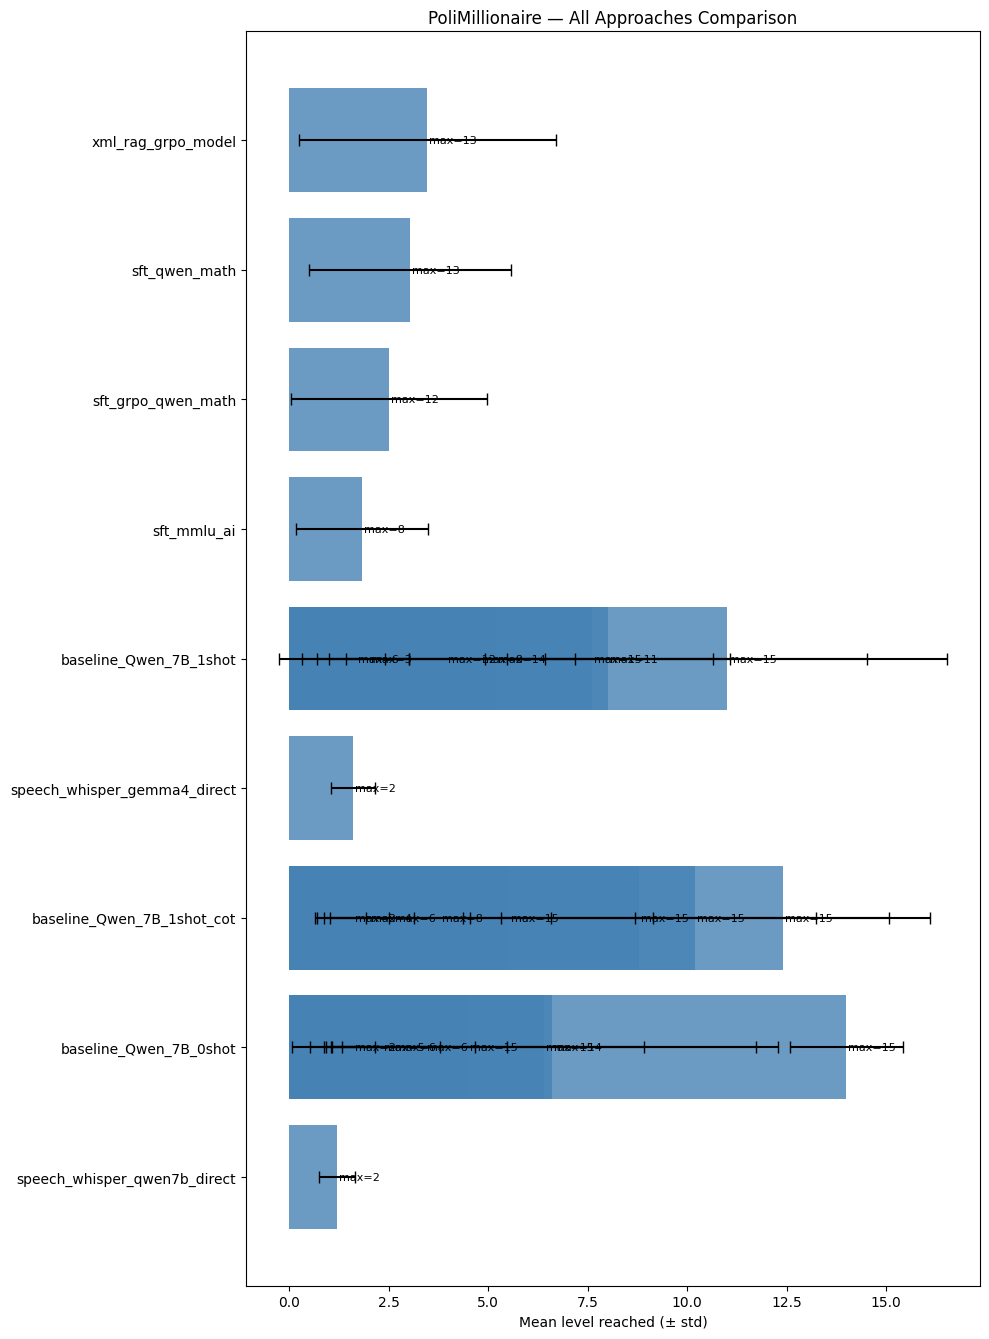

In [ ]:
# 9.2  Visualisation
plot_results(RESULTS_CSV)


## Section 10 — Speech Mode: Whisper STT Pipeline

The PoliMillionaire API supports a **speech game mode** where questions and
options are served as WAV audio. This section adds:

1. `openai-whisper` for automatic speech recognition
2. `_transcribe(wav_bytes)` helper
3. `play_game_speech(answer_fn, competition_id)` — a full speech game loop
   that fetches audio, transcribes it with Whisper, then uses any `answer_fn`
   (e.g. `ask_final` or `answer` from §10/§6) to submit the answer

> **Timer note:** the 30-second clock starts **after the last option audio is
> fetched** (not at question start). The pipeline fetches all audio first,
> then calls the answer function, to avoid racing the timer.


In [ ]:
%%capture
!pip install -q openai-whisper


In [ ]:
import whisper as _whisper, tempfile, os

print("Loading Whisper base model...")
whisper_model = _whisper.load_model("base")
print("Whisper ready.")

def _transcribe(wav_bytes: bytes, fallback: str = "") -> str:
    """Transcribe a WAV byte string via Whisper. Returns text or fallback."""
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        tmp.write(wav_bytes)
        tmp_path = tmp.name
    try:
        result = whisper_model.transcribe(tmp_path, fp16=False, language="en")
        text   = result["text"].strip()
        return text if text else fallback
    except Exception as e:
        print(f"  [Whisper] transcription error: {e}")
        return fallback
    finally:
        os.unlink(tmp_path)


Loading Whisper base model...


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 431MiB/s]


Whisper ready.


In [ ]:
import warnings, sys, os, re, statistics, time
import pandas as pd
from datetime import datetime
warnings.filterwarnings("ignore")
_orig_stderr = sys.stderr
sys.stderr = open(os.devnull, "w")

def play_game_speech(answer_fn, competition_id: int, target_runs: int = 5,
                     anti_ban_pause: int = 20, label: str = "speech") -> dict:
    levels_reached  = []
    successful_runs = 0

    print(f"\n{'='*60}")
    print(f"Speech benchmark: {label}  |  comp={competition_id}  |  runs={target_runs}")
    print(f"{'='*60}")

    while successful_runs < target_runs:
        print(f"\n[{successful_runs+1}/{target_runs}] Starting speech game...", flush=True)
        try:
            game = client.game.start(competition_id=competition_id, mode="speech")
            print(f"  Session {game.session_id} | levels: {game.state.competition.max_levels}")

            while game.in_progress:
                q = game.current_question
                if not q:
                    break

                q_audio       = game.fetch_audio_question()
                q_transcribed = _transcribe(q_audio, fallback=q.text)
                print(f"  [Q] {q_transcribed[:80]}")

                for opt in q.options:
                    opt_audio = game.fetch_audio_option_next()
                    opt_text  = _transcribe(opt_audio, fallback=opt.text)
                    print(f"    [{opt.id}] {opt_text[:50]}")

                answer_id = answer_fn(q_transcribed, q.options, competition_id)
                print(f"  → submitting [{answer_id}]", flush=True)

                result = game.answer(answer_id)

                if result.timed_out:
                    print("  TIMED OUT!")
                    break
                elif result.correct:
                    print(f"  CORRECT  level={game.current_level}  earned=${result.earned_amount:,.0f}")
                else:
                    print(f"  WRONG    earned=${result.earned_amount:,.0f}")

                if result.game_over:
                    break

            levels_reached.append(game.current_level)
            successful_runs += 1
            print(f"  Game over. Level reached: {game.current_level}")

            if successful_runs < target_runs:
                time.sleep(anti_ban_pause)

        except Exception as exc:
            print(f"  [!] {exc} — retrying in 60s...")
            time.sleep(60)

    if not levels_reached:
        sys.stderr.close(); sys.stderr = _orig_stderr
        return {}

    mean_val = statistics.mean(levels_reached)
    var_val  = statistics.variance(levels_reached) if len(levels_reached) > 1 else 0.0
    max_val  = max(levels_reached)

    print(f"\nSpeech results: mean={mean_val:.2f}  var={var_val:.2f}  max={max_val}")

    row = pd.DataFrame([{
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "label": label, "competition_id": competition_id,
        "mean_level": round(mean_val, 2), "variance": round(var_val, 2),
        "max_level": max_val,
    }])
    if os.path.isfile(RESULTS_CSV):
        row.to_csv(RESULTS_CSV, mode="a", header=False, index=False)
    else:
        row.to_csv(RESULTS_CSV, index=False)

    sys.stderr.close(); sys.stderr = _orig_stderr
    return {"label": label, "mean_level": round(mean_val,2),
            "variance": round(var_val,2), "max_level": max_val,
            "all_levels": levels_reached}


def _answer_qwen7b_direct(question_text, options, competition_id):
    model     = ensemble_models["Qwen_7B"]
    tok       = ensemble_tokenizers["Qwen_7B"]
    valid_ids = [int(opt.id) for opt in options]
    opts_txt  = "\n".join(f"{opt.id}: {opt.text}" for opt in options)
    messages  = [{"role": "user",
                  "content": (f"Question: {question_text}\n\nOptions:\n{opts_txt}\n\n"
                              "Reply with ONLY the correct option number.")}]
    prompt  = tok.apply_chat_template(messages, tokenize=False,
                                       add_generation_prompt=True)
    inputs  = tok(prompt, return_tensors="pt",
                  truncation=True, max_length=512).to(model.device)
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=1, do_sample=False,
                             pad_token_id=tok.eos_token_id)
    raw = tok.decode(out[0][inputs["input_ids"].shape[1]:],
                     skip_special_tokens=True)
    for m in re.finditer(r"\b(\d+)\b", raw):
        idx = int(m.group(1))
        if idx in valid_ids:
            return idx
    return valid_ids[0]


play_game_speech(_answer_qwen7b_direct, competition_id=0, target_runs=5,
                 label="speech_whisper_qwen7b_direct")


,============================================================
,Speech benchmark: speech_whisper_qwen7b_direct  |  comp=0  |  runs=5
,============================================================
,
,[1/5] Starting speech game...
,  Session 376285 | levels: 15
,  [Q] What was the fundamental principle of John Lennon's songwriting with Paul McCart
,    [0] Option A. Collaboration
,    [1] Option B. Solo work!
,    [2] Option C, Competition!
,    [3] Topsy and D. Harmony.
,  → submitting [3]
,  WRONG    earned=$0
,  Game over. Level reached: 1
,
,[2/5] Starting speech game...
,  Session 376289 | levels: 15
,  [Q] Which of the following best describes the Skywalker saga in the Star Wars franch
,    [0] Option A, the original trilogy of films.
,    [1] Option B, the prequel trilogy of films.
,    [2] Option C, the spin-off films such as Rogue One and
,    [3] Topsyndee, the combined nine films, including the 
,  → submitting [0]
,  WRONG    earned=$0
,  Game over. Level reached: 1
,
,[3/5] S

{'label': 'speech_whisper_qwen7b_direct',
 'mean_level': 1.2,
 'variance': 0.2,
 'max_level': 2,
 'all_levels': [1, 1, 1, 1, 2]}